<a href="https://colab.research.google.com/github/archishacs28-wq/MINOR_PROJECT-2CSE12-Github/blob/main/ISL_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Indian Sign Language (ISL) Detection using CNN + Transfer Learning
### Deep Learning Project — A–Z (26 classes) + 1–9 (9 classes) = **35 Classes**

---
**Architecture:** MobileNetV2 (Transfer Learning)  
**Framework:** TensorFlow / Keras  
**Platform:** Google Colab (GPU)  
**Target Accuracy:** > 95%  

---
**Project Pipeline:**
1. Import Libraries
2. Dataset Setup (Kaggle / Google Drive)
3. Data Visualization
4. Data Preprocessing & Augmentation
5. Train-Validation Split
6. Model Architecture (MobileNetV2)
7. Compile & Train
8. Evaluation + Graphs
9. Confusion Matrix
10. Classification Report
11. Sample Predictions + Confidence
12. Save & Export (H5 + TFLite)

##  STEP 0: Install & Setup Runtime
> Make sure to select **Runtime → Change runtime type → T4 GPU** before running!

In [ ]:
# Verify GPU availability
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

# Install required libraries (if not already present)
!pip install -q kaggle opencv-python-headless seaborn scikit-learn matplotlib

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## DATASET SETUP


**Dataset Used:** [ISL Alphabet + Digits Dataset](https://www.kaggle.com/datasets/prathumarikeri/indian-sign-language-isl)

This dataset contains images for all **A–Z** alphabets and **0–9** digits in Indian Sign Language, organized into 36 class folders.

In [ ]:
import os

# ─────────────────────────────────────────────────────────────────
# OPTION A: Download Dataset from Kaggle
# ─────────────────────────────────────────────────────────────────
# Step 1: Upload your kaggle.json API key
# Go to kaggle.com → Account → Create New API Token → Upload below

USE_KAGGLE = True   # Set False to use Google Drive instead

if USE_KAGGLE:
    from google.colab import files
    print('Upload your kaggle.json file:')
    uploaded = files.upload()

    # Configure Kaggle credentials
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    # Download ISL dataset
    print('\nDownloading dataset...')
    !kaggle datasets download -d prathumarikeri/indian-sign-language-isl -p /content/
    print('\nExtracting...')
    !unzip -q /content/indian-sign-language-isl.zip -d /content/dataset_raw/
    print('Done!')
    !ls /content/dataset_raw/

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/prathumarikeri/indian-sign-language-isl
License(s): CC-BY-SA-4.0
100% 281M/281M [00:05<00:00, 52.7MB/s]


Extracting...
Done!
Indian


In [ ]:
# ─────────────────────────────────────────────────────────────────
# OPTION B: Load from Google Drive
# ─────────────────────────────────────────────────────────────────


USE_DRIVE = False

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    # Update this path to your dataset location in Drive:
    DRIVE_DATASET_PATH = '/content/drive/MyDrive/ISL_Dataset/'
    print(f'Dataset mounted from: {DRIVE_DATASET_PATH}')
    !ls "{DRIVE_DATASET_PATH}"

In [ ]:
# ─────────────────────────────────────────────────────────────────
# AUTO-DETECT DATASET ROOT PATH
# ─────────────────────────────────────────────────────────────────
import os
import glob

def find_dataset_root(search_dirs):
    """Automatically locate the dataset root containing class folders."""
    for base in search_dirs:
        if not os.path.exists(base):
            continue
        for root, dirs, files in os.walk(base):
            # Check if directory contains expected class folders
            subdirs = set(os.listdir(root))
            expected = {'A', 'B', 'C', '0', '1', '2'}
            if expected.issubset(subdirs) or len(subdirs) >= 30:
                return root
    return None

search_locations = [
    '/content/dataset_raw',
    '/content/dataset',
    '/content/drive/MyDrive/ISL_Dataset',
    '/content/ISL_Dataset',
]

DATASET_PATH = find_dataset_root(search_locations)

if DATASET_PATH:
    print(f' Dataset found at: {DATASET_PATH}')
    classes_found = sorted(os.listdir(DATASET_PATH))
    print(f'Classes found ({len(classes_found)}): {classes_found}')
else:
    # Fallback: manually set
    DATASET_PATH = '/content/dataset_raw'
    print(f' Dataset not auto-found. Using: {DATASET_PATH}')
    print('Please update DATASET_PATH manually if required.')

✅ Dataset found at: /content/dataset_raw/Indian
Classes found (35): ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


## STEP 1: Import Libraries

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 1: IMPORT ALL REQUIRED LIBRARIES
# ─────────────────────────────────────────────────────────────────

# Core
import os
import json
import random
import warnings
import numpy as np
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Image processing
import cv2
from PIL import Image

# Machine Learning utilities
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Set random seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('=' * 55)
print('   All Libraries Imported Successfully')
print('=' * 55)
print(f'  TensorFlow  : {tf.__version__}')
print(f'  Keras       : {keras.__version__}')
print(f'  NumPy       : {np.__version__}')
print(f'  OpenCV      : {cv2.__version__}')
print(f'  GPU Devices : {tf.config.list_physical_devices("GPU")}')
print('=' * 55)

  ✅ All Libraries Imported Successfully
  TensorFlow  : 2.19.0
  Keras       : 3.13.2
  NumPy       : 2.0.2
  OpenCV      : 4.13.0
  GPU Devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  GLOBAL CONFIGURATION

In [ ]:
# ─────────────────────────────────────────────────────────────────
# GLOBAL HYPERPARAMETERS & CONFIGURATION
# ─────────────────────────────────────────────────────────────────

# Image configuration
IMG_HEIGHT    = 224          # MobileNetV2 default input size
IMG_WIDTH     = 224
IMG_SIZE      = (IMG_HEIGHT, IMG_WIDTH)
IMG_CHANNELS  = 3
INPUT_SHAPE   = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# Dataset configuration
NUM_CLASSES   = 36           # A-Z (26) + 0-9 (10)
BATCH_SIZE    = 32
VALIDATION_SPLIT = 0.20     # 80% train, 20% validation

# Training configuration
INITIAL_LR    = 0.001        # Initial learning rate
FINETUNE_LR   = 0.0001       # Fine-tuning learning rate
EPOCHS_FROZEN = 15           # Epochs with frozen base model
EPOCHS_FINETUNE = 10         # Epochs during fine-tuning
DROPOUT_RATE  = 0.5

# Output paths
OUTPUT_DIR    = '/content/isl_output'
MODEL_H5_PATH = os.path.join(OUTPUT_DIR, 'isl_model.h5')
LABELS_PATH   = os.path.join(OUTPUT_DIR, 'class_labels.json')
TFLITE_PATH   = os.path.join(OUTPUT_DIR, 'isl_model.tflite')
BEST_MODEL    = os.path.join(OUTPUT_DIR, 'best_model.h5')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class labels: 0–9 first, then A–Z
DIGIT_CLASSES = [str(i) for i in range(10)]           # ['0','1',...,'9']
ALPHA_CLASSES = [chr(i) for i in range(ord('A'), ord('Z')+1)]  # ['A','B',...,'Z']
ALL_CLASSES   = DIGIT_CLASSES + ALPHA_CLASSES          # 36 classes total

print('Configuration Summary:')
print(f'  Image Size     : {IMG_SIZE}')
print(f'  Batch Size     : {BATCH_SIZE}')
print(f'  Num Classes    : {NUM_CLASSES}')
print(f'  Val Split      : {VALIDATION_SPLIT*100:.0f}%')
print(f'  Epochs (Phase1): {EPOCHS_FROZEN}')
print(f'  Epochs (Phase2): {EPOCHS_FINETUNE}')
print(f'  Output Dir     : {OUTPUT_DIR}')
print(f'  Classes        : {ALL_CLASSES}')

Configuration Summary:
  Image Size     : (224, 224)
  Batch Size     : 32
  Num Classes    : 36
  Val Split      : 20%
  Epochs (Phase1): 15
  Epochs (Phase2): 10
  Output Dir     : /content/isl_output
  Classes        : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


##  STEP 2: Dataset Visualization

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 2A: DATASET SUMMARY STATISTICS
# ─────────────────────────────────────────────────────────────────

class_counts = {}
total_images = 0
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')

for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(valid_extensions)
        ])
        class_counts[cls] = count
        total_images += count

detected_classes = sorted(class_counts.keys())
NUM_CLASSES = len(detected_classes)

print('=' * 60)
print('         INDIAN SIGN LANGUAGE DATASET SUMMARY')
print('=' * 60)
print(f'  Total Classes  : {NUM_CLASSES}')
print(f'  Total Images   : {total_images:,}')
print(f'  Avg per Class  : {total_images // NUM_CLASSES:,}')
print(f'  Min per Class  : {min(class_counts.values()):,}  ({min(class_counts, key=class_counts.get)})')
print(f'  Max per Class  : {max(class_counts.values()):,}  ({max(class_counts, key=class_counts.get)})')
print('=' * 60)
print('\nPer-Class Distribution:')
print('-' * 40)
for cls, cnt in sorted(class_counts.items()):
    bar = '█' * (cnt // max(class_counts.values()) * 20 + 1)
    print(f'  {cls:>4} : {cnt:>5} images')
print('=' * 60)

         INDIAN SIGN LANGUAGE DATASET SUMMARY
  Total Classes  : 35
  Total Images   : 42,745
  Avg per Class  : 1,221
  Min per Class  : 1,200  (1)
  Max per Class  : 1,447  (C)

Per-Class Distribution:
----------------------------------------
     1 :  1200 images
     2 :  1200 images
     3 :  1200 images
     4 :  1200 images
     5 :  1200 images
     6 :  1200 images
     7 :  1200 images
     8 :  1200 images
     9 :  1200 images
     A :  1200 images
     B :  1200 images
     C :  1447 images
     D :  1200 images
     E :  1200 images
     F :  1200 images
     G :  1200 images
     H :  1200 images
     I :  1379 images
     J :  1200 images
     K :  1200 images
     L :  1200 images
     M :  1200 images
     N :  1200 images
     O :  1429 images
     P :  1200 images
     Q :  1200 images
     R :  1200 images
     S :  1200 images
     T :  1200 images
     U :  1200 images
     V :  1290 images
     W :  1200 images
     X :  1200 images
     Y :  1200 images
     Z 

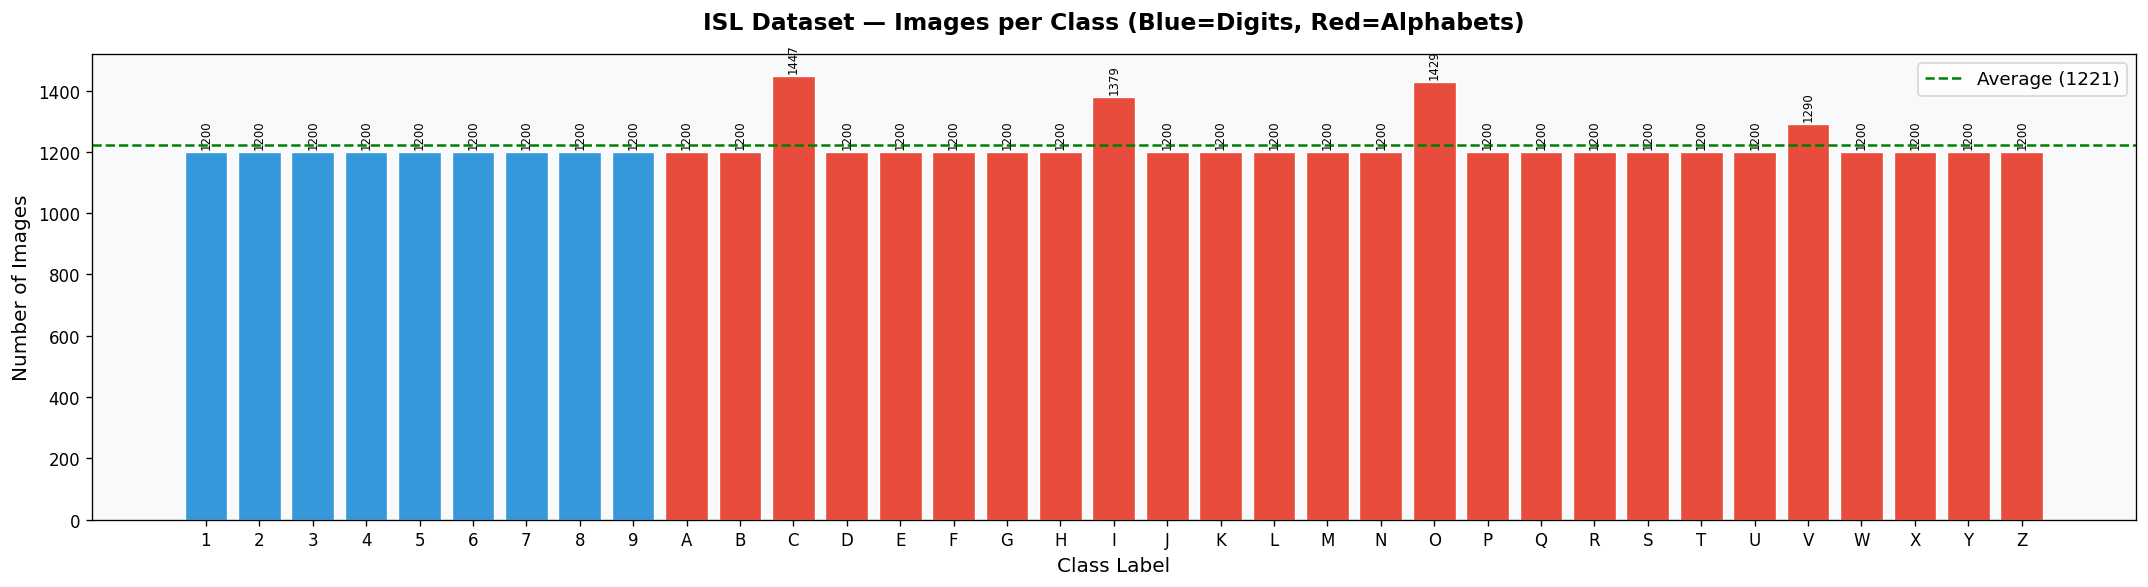

✅ Class distribution chart saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 2B: CLASS DISTRIBUTION BAR CHART
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(18, 5))
classes_sorted = sorted(class_counts.keys())
counts_sorted  = [class_counts[c] for c in classes_sorted]

colors = ['#3498db' if c.isdigit() else '#e74c3c' for c in classes_sorted]
bars = ax.bar(classes_sorted, counts_sorted, color=colors, edgecolor='white', linewidth=0.8)

for bar, count in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_title('ISL Dataset — Images per Class (Blue=Digits, Red=Alphabets)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Class Label', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.axhline(y=total_images // NUM_CLASSES, color='green', linestyle='--',
           linewidth=1.5, label=f'Average ({total_images // NUM_CLASSES})')
ax.legend(fontsize=11)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Class distribution chart saved.')

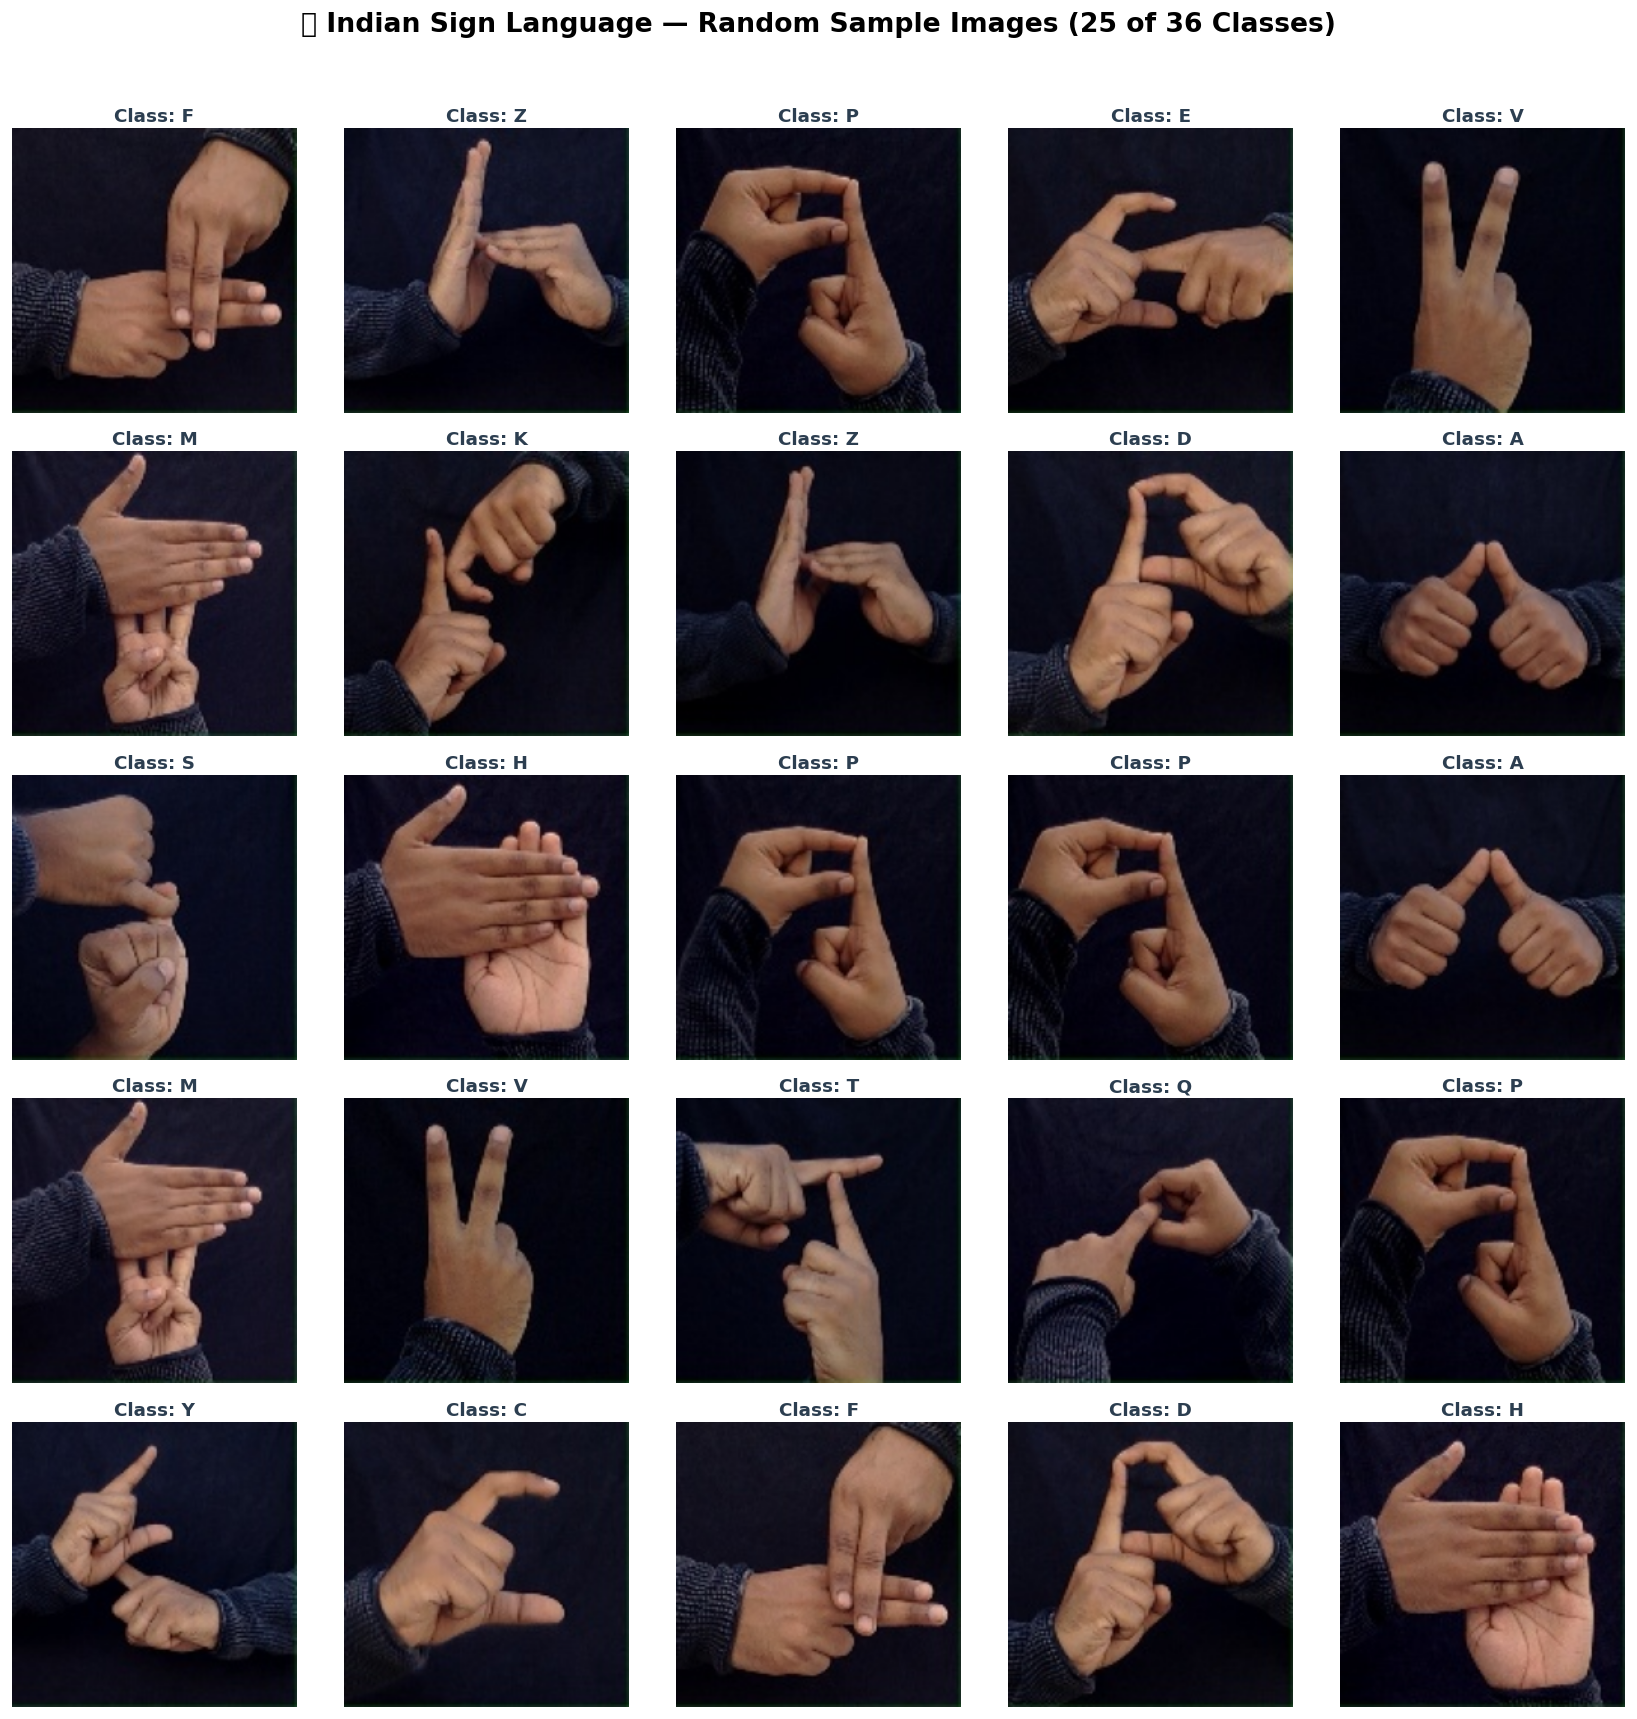

✅ Sample grid (25 images) saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 2C: VISUALIZE 25 RANDOM IMAGES IN 5×5 GRID
# ─────────────────────────────────────────────────────────────────

def show_random_samples(dataset_path, n_samples=25, grid=(5, 5), figsize=(14, 14)):
    """Display random sample images from the dataset in a grid layout."""
    all_images_info = []  # list of (image_path, class_label)

    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(valid_extensions):
                all_images_info.append((os.path.join(cls_path, fname), cls))

    # Sample randomly
    selected = random.sample(all_images_info, min(n_samples, len(all_images_info)))

    fig, axes = plt.subplots(grid[0], grid[1], figsize=figsize)
    fig.suptitle(' Indian Sign Language — Random Sample Images (25 of 36 Classes)',
                 fontsize=16, fontweight='bold', y=1.02)

    for idx, ax in enumerate(axes.flat):
        if idx < len(selected):
            img_path, label = selected[idx]
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                ax.imshow(img)
                ax.set_title(f'Class: {label}', fontsize=11, fontweight='bold',
                             color='#2c3e50', pad=4)
            except Exception as e:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f' Sample grid (25 images) saved.')

show_random_samples(DATASET_PATH)

##  STEP 3 & 4: Data Preprocessing, Augmentation & Train/Val Split

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 3 & 4: DATA GENERATORS WITH AUGMENTATION
# ─────────────────────────────────────────────────────────────────

# ── Training Data Generator (with strong augmentation) ───────────
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255.0,     # Normalize pixel values to [0, 1]
    rotation_range     = 20,              # Random rotation up to ±20 degrees
    zoom_range         = 0.20,            # Random zoom in/out by 20%
    width_shift_range  = 0.15,            # Horizontal shift
    height_shift_range = 0.15,            # Vertical shift
    shear_range        = 0.15,            # Shear transformation
    horizontal_flip    = True,            # Mirror images horizontally
    brightness_range   = [0.7, 1.3],      # ★ Brightness variation (IMPORTANT)
    fill_mode          = 'nearest',       # Fill strategy for empty pixels
    validation_split   = VALIDATION_SPLIT # 80/20 split
)

# ── Validation Data Generator (NO augmentation, only normalization) ──
val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255.0,
    validation_split = VALIDATION_SPLIT
)

# ── Training Generator ────────────────────────────────────────────
train_generator = train_datagen.flow_from_directory(
    directory    = DATASET_PATH,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    shuffle      = True,
    seed         = SEED,
    color_mode   = 'rgb'
)

# ── Validation Generator ──────────────────────────────────────────
val_generator = val_datagen.flow_from_directory(
    directory    = DATASET_PATH,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    shuffle      = False,   # Keep order for evaluation
    seed         = SEED,
    color_mode   = 'rgb'
)

# ── Extract class information ─────────────────────────────────────
CLASS_INDICES = train_generator.class_indices          # {'0': 0, '1': 1, ..., 'A': 10, ...}
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()} # {0: '0', ..., 10: 'A', ...}
CLASS_NAMES   = [IDX_TO_CLASS[i] for i in range(len(IDX_TO_CLASS))]
NUM_CLASSES   = len(CLASS_NAMES)

# Update NUM_CLASSES based on actual detected classes
print('=' * 55)
print('     DATA GENERATORS SUMMARY')
print('=' * 55)
print(f'  Training Samples   : {train_generator.n:,}')
print(f'  Validation Samples : {val_generator.n:,}')
print(f'  Number of Classes  : {NUM_CLASSES}')
print(f'  Batch Size         : {BATCH_SIZE}')
print(f'  Steps/Epoch (Train): {train_generator.n // BATCH_SIZE}')
print(f'  Steps/Epoch (Val)  : {val_generator.n // BATCH_SIZE}')
print(f'  Class Names        : {CLASS_NAMES}')
print('=' * 55)

Found 34198 images belonging to 35 classes.
Found 8547 images belonging to 35 classes.
     DATA GENERATORS SUMMARY
  Training Samples   : 34,198
  Validation Samples : 8,547
  Number of Classes  : 35
  Batch Size         : 32
  Steps/Epoch (Train): 1068
  Steps/Epoch (Val)  : 267
  Class Names        : ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


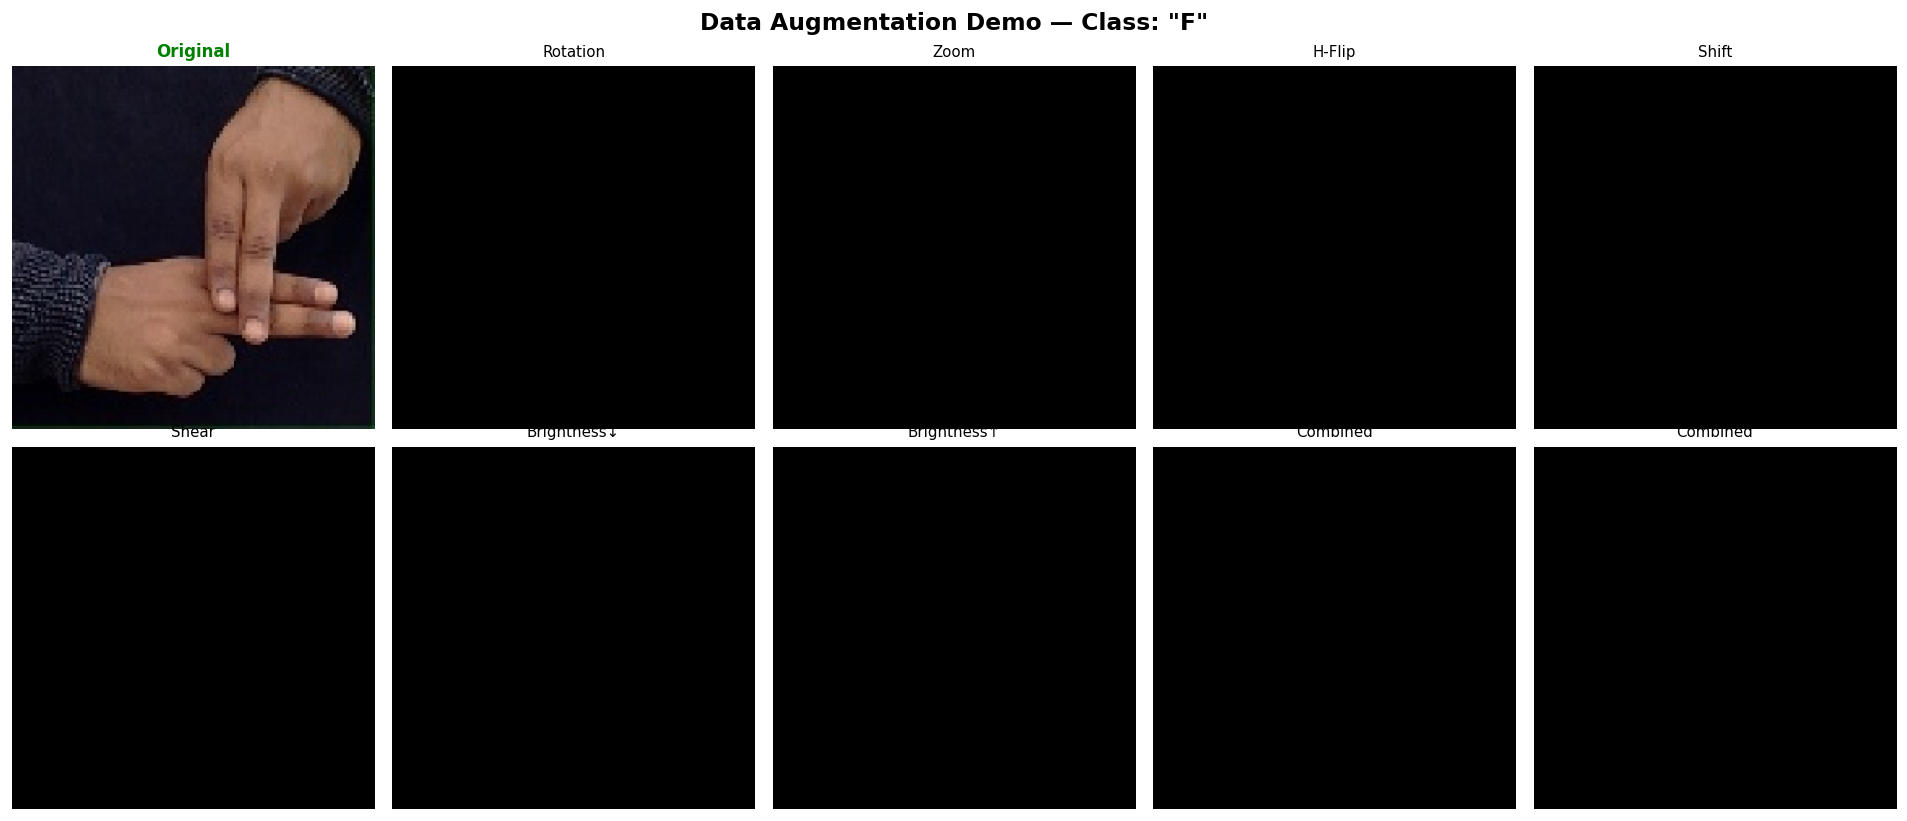

✅ Augmentation demo saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# VISUALIZE AUGMENTATION EFFECT ON A SAMPLE IMAGE
# ─────────────────────────────────────────────────────────────────

# Pick one sample image to show augmentation variants
sample_class = random.choice(list(class_counts.keys()))
sample_dir   = os.path.join(DATASET_PATH, sample_class)
sample_img_name = random.choice([
    f for f in os.listdir(sample_dir)
    if f.lower().endswith(valid_extensions)
])
sample_img_path = os.path.join(sample_dir, sample_img_name)

# Load and preprocess for augmentation demo
aug_demo_gen = ImageDataGenerator(
    rotation_range     = 20,
    zoom_range         = 0.20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    shear_range        = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.7, 1.3],
    fill_mode          = 'nearest'
)

img_orig = load_img(sample_img_path, target_size=IMG_SIZE)
img_arr  = img_to_array(img_orig) / 255.0
img_arr  = np.expand_dims(img_arr, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(f'Data Augmentation Demo — Class: "{sample_class}"',
             fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(img_orig)
axes[0, 0].set_title('Original', fontsize=10, color='green', fontweight='bold')
axes[0, 0].axis('off')

# Augmented versions
flat_axes = [ax for row in axes for ax in row][1:]  # skip first (original)
aug_iter  = aug_demo_gen.flow(img_arr, batch_size=1, seed=SEED)

aug_labels = ['Rotation', 'Zoom', 'H-Flip', 'Shift', 'Shear',
              'Brightness↓', 'Brightness↑', 'Combined', 'Combined']
for i, ax in enumerate(flat_axes):
    aug_img = next(aug_iter)[0]
    ax.imshow(np.clip(aug_img, 0, 1))
    label = aug_labels[i] if i < len(aug_labels) else f'Aug {i+1}'
    ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'augmentation_demo.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Augmentation demo saved.')

##  STEP 5: Model Architecture — MobileNetV2 Transfer Learning

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 5: BUILD MODEL — MobileNetV2 + CUSTOM HEAD
# ─────────────────────────────────────────────────────────────────

def build_isl_model(num_classes, input_shape, dropout_rate=0.5):
    """
    Builds ISL detection model using MobileNetV2 as frozen base.

    Architecture:
      MobileNetV2 (frozen, ImageNet weights)
      → GlobalAveragePooling2D
      → BatchNormalization
      → Dense(512, relu)
      → Dropout(0.5)
      → Dense(256, relu)
      → Dropout(0.3)
      → Dense(num_classes, softmax)
    """
    # ── Base Model: MobileNetV2 (pre-trained on ImageNet) ──────────
    base_model = MobileNetV2(
        input_shape = input_shape,
        include_top = False,       # Remove ImageNet classification head
        weights     = 'imagenet'   # Use pre-trained weights
    )

    # Freeze base model layers (Phase 1 training)
    base_model.trainable = False
    print(f'Base model layers    : {len(base_model.layers)}')
    print(f'Trainable parameters : 0 (frozen for Phase 1)')

    # ── Build Custom Classification Head ──────────────────────────
    inputs = keras.Input(shape=input_shape, name='input_layer')

    # Pass through frozen base
    x = base_model(inputs, training=False)

    # Global Average Pooling — reduces spatial dimensions
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    # Batch Normalization — stabilizes and speeds up training
    x = layers.BatchNormalization(name='batch_norm_1')(x)

    # First Dense Block
    x = layers.Dense(512, activation='relu', name='dense_512',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)  # 50% dropout

    # Second Dense Block
    x = layers.BatchNormalization(name='batch_norm_2')(x)
    x = layers.Dense(256, activation='relu', name='dense_256',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)           # 30% dropout

    # Output layer — Softmax for multi-class probabilities
    outputs = layers.Dense(num_classes, activation='softmax',
                           name='output_softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='ISL_MobileNetV2')
    return model, base_model


# Build the model
model, base_model = build_isl_model(
    num_classes  = NUM_CLASSES,
    input_shape  = INPUT_SHAPE,
    dropout_rate = DROPOUT_RATE
)

# Print model summary
print('\n' + '=' * 65)
print('          MODEL ARCHITECTURE SUMMARY')
print('=' * 65)
model.summary()

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen_params    = total_params - trainable_params

print('\n' + '=' * 65)
print(f'  Total Parameters    : {total_params:,}')
print(f'  Trainable           : {trainable_params:,}')
print(f'  Frozen (MobileNetV2): {frozen_params:,}')
print('=' * 65)

##  STEP 6: Compile Model

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 6: COMPILE MODEL
# ─────────────────────────────────────────────────────────────────

model.compile(
    optimizer = Adam(learning_rate=INITIAL_LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('Model compiled with:')
print(f'  Optimizer : Adam (lr={INITIAL_LR})')
print(f'  Loss      : categorical_crossentropy')
print(f'  Metrics   : accuracy')

Model compiled with:
  Optimizer : Adam (lr=0.001)
  Loss      : categorical_crossentropy
  Metrics   : accuracy


##  STEP 7: Train Model — Phase 1 (Frozen Base)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 7A: DEFINE CALLBACKS
# ─────────────────────────────────────────────────────────────────

callbacks_phase1 = [
    # Stop training if validation accuracy doesn't improve for 7 epochs
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 7,
        restore_best_weights = True,
        mode                 = 'max',
        verbose              = 1
    ),
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.3,
        patience  = 3,
        min_lr    = 1e-7,
        mode      = 'min',
        verbose   = 1
    ),
    # Save best model during training
    ModelCheckpoint(
        filepath        = BEST_MODEL,
        monitor         = 'val_accuracy',
        save_best_only  = True,
        mode            = 'max',
        verbose         = 0
    )
]

print('Callbacks configured:')
print('   EarlyStopping    (patience=7, monitor=val_accuracy)')
print('   ReduceLROnPlateau(patience=3, factor=0.3)')
print('   ModelCheckpoint  (saving best model to .h5)')

Callbacks configured:
  ✅ EarlyStopping    (patience=7, monitor=val_accuracy)
  ✅ ReduceLROnPlateau(patience=3, factor=0.3)
  ✅ ModelCheckpoint  (saving best model to .h5)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 7B: PHASE 1 TRAINING (FROZEN BASE MODEL)
# ─────────────────────────────────────────────────────────────────


print('   PHASE 1: Training Custom Head (Base Model Frozen)')

from tensorflow.keras.callbacks import EarlyStopping

callbacks_phase1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True,
        verbose=1
    )
]

history_phase1 = model.fit(
    train_generator,
    epochs          = EPOCHS_FROZEN,
    validation_data = val_generator,
    callbacks       = callbacks_phase1,
    verbose         = 1
)

# Report Phase 1 results
best_val_acc_p1 = max(history_phase1.history['val_accuracy'])
print(f'\n Phase 1 Complete!')
print(f'   Best Val Accuracy: {best_val_acc_p1 * 100:.2f}%')

  🏋️  PHASE 1: Training Custom Head (Base Model Frozen)
Epoch 1/15
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 464s 433ms/step - accuracy: 0.9947 - loss: 0.1268 - val_accuracy: 0.9902 - val_loss: 0.1681
Epoch 2/15
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 450s 421ms/step - accuracy: 0.9944 - loss: 0.1305 - val_accuracy: 0.9887 - val_loss: 0.2364
Epoch 3/15
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 447s 418ms/step - accuracy: 0.9951 - loss: 0.1311 - val_accuracy: 0.9730 - val_loss: 0.2390
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

✅ Phase 1 Complete!
   Best Val Accuracy: 99.02%


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 7C: PHASE 2 — FINE-TUNING (UNFREEZE LAST LAYERS)
# ─────────────────────────────────────────────────────────────────


print('    PHASE 2: Fine-Tuning (Unfreezing Last 30 Layers)')


# Unfreeze top portion of the base model for fine-tuning
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f'  Unfrozen layers: {unfrozen} (fine-tuning from layer {FINE_TUNE_AT})')

# Re-compile with lower learning rate for fine-tuning
model.compile(
    optimizer = Adam(learning_rate=FINETUNE_LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Fine-tuning callbacks with stricter early stopping
callbacks_phase2 = [
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        mode                 = 'max',
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.3,
        patience  = 2,
        min_lr    = 1e-8,
        mode      = 'min',
        verbose   = 1
    ),
    ModelCheckpoint(
        filepath       = BEST_MODEL,
        monitor        = 'val_accuracy',
        save_best_only = True,
        mode           = 'max',
        verbose        = 0
    )
]
EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 2,
    restore_best_weights = True,
    mode                 = 'max',
    verbose              = 1
)

# Phase 2 Training
history_phase2 = model.fit(
    train_generator,
    epochs          = EPOCHS_FINETUNE,
    validation_data = val_generator,
    callbacks       = callbacks_phase2,
    verbose         = 1
)

best_val_acc_p2 = max(history_phase2.history['val_accuracy'])
print(f'\n Phase 2 Complete')
print(f'   Best Val Accuracy: {best_val_acc_p2 * 100:.2f}%')

    PHASE 2: Fine-Tuning (Unfreezing Last 30 Layers)
  Unfrozen layers: 30 (fine-tuning from layer 124)
Epoch 1/10
 700/1069 ━━━━━━━━━━━━━━━━━━━━ 3:21 547ms/step - accuracy: 0.9994 - loss: 0.0811

In [ ]:
# ─────────────────────────────────────────────────────────────────
# MERGE BOTH PHASE HISTORIES FOR UNIFIED PLOTS
# ─────────────────────────────────────────────────────────────────

def merge_histories(h1, h2):
    """Concatenate Phase 1 and Phase 2 training histories."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

HISTORY = merge_histories(history_phase1, history_phase2)
TOTAL_EPOCHS = len(HISTORY['accuracy'])
phase1_end   = len(history_phase1.history['accuracy'])

print(f'Total training epochs : {TOTAL_EPOCHS}')
print(f'Phase 1 ended at      : epoch {phase1_end}')
print(f'Phase 2 epochs        : {TOTAL_EPOCHS - phase1_end}')
print(f'Final Val Accuracy    : {HISTORY["val_accuracy"][-1] * 100:.2f}%')
print(f'Best  Val Accuracy    : {max(HISTORY["val_accuracy"]) * 100:.2f}%')

Total training epochs : 10
Phase 1 ended at      : epoch 3
Phase 2 epochs        : 7
Final Val Accuracy    : 98.97%
Best  Val Accuracy    : 99.02%


##  STEP 8: Model Evaluation

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 8: EVALUATE ON VALIDATION SET
# ─────────────────────────────────────────────────────────────────

# Load best saved checkpoint
if os.path.exists(BEST_MODEL):
    model = keras.models.load_model(BEST_MODEL)
    print(f' Loaded best model from: {BEST_MODEL}')

# Evaluate
val_generator.reset()
val_loss, val_acc = model.evaluate(val_generator, verbose=1)

print('\n' + '=' * 50)
print('       FINAL EVALUATION RESULTS')
print('=' * 50)
print(f'  Validation Loss     : {val_loss:.4f}')
print(f'  Validation Accuracy : {val_acc * 100:.2f}%')
print('=' * 50)

if val_acc >= 0.95:
    print('    Accuracy > 95%!')
elif val_acc >= 0.90:
    print('   Good performance! Consider more fine-tuning.')
else:
    print('    Consider increasing epochs or adjusting augmentation.')

 Loaded best model from: /content/isl_output/best_model.h5
268/268 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9899 - loss: 0.1579

       FINAL EVALUATION RESULTS
  Validation Loss     : 0.1579
  Validation Accuracy : 98.99%
    Accuracy > 95%!


##  STEP 9: Training History Graphs

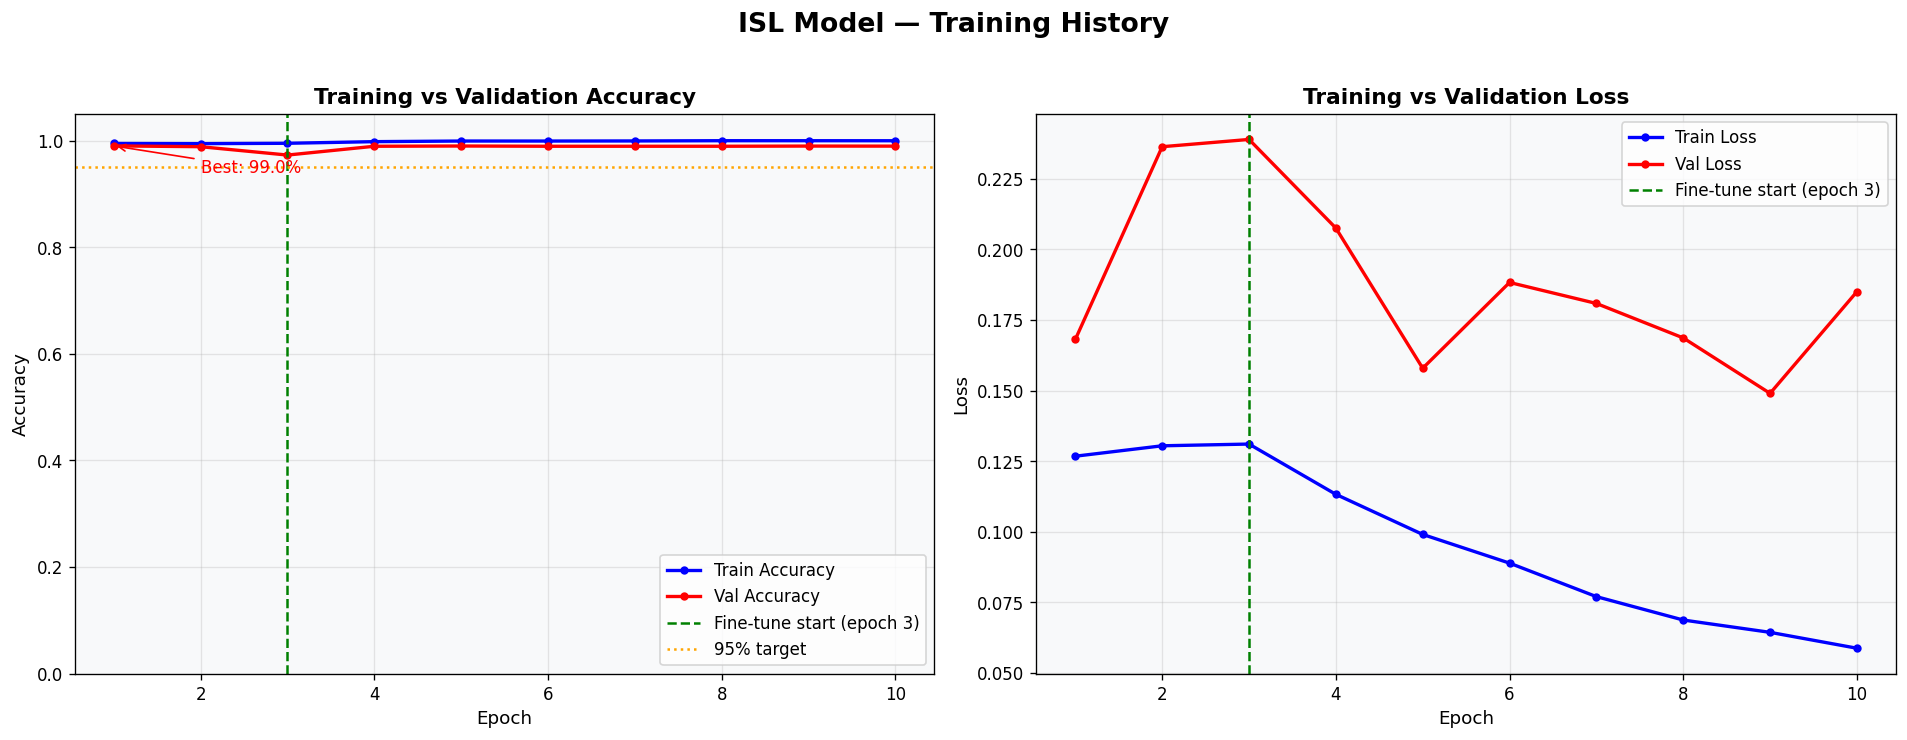

Training history plot saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 9: PLOT TRAINING vs VALIDATION ACCURACY & LOSS
# ─────────────────────────────────────────────────────────────────

epochs_range = range(1, TOTAL_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ISL Model — Training History', fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Accuracy ──────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_range, HISTORY['accuracy'],
         'b-o', markersize=4, linewidth=2, label='Train Accuracy')
ax1.plot(epochs_range, HISTORY['val_accuracy'],
         'r-o', markersize=4, linewidth=2, label='Val Accuracy')
ax1.axvline(x=phase1_end, color='green', linestyle='--',
            linewidth=1.5, label=f'Fine-tune start (epoch {phase1_end})')
ax1.axhline(y=0.95, color='orange', linestyle=':', linewidth=1.5, label='95% target')
best_epoch = np.argmax(HISTORY['val_accuracy']) + 1
best_acc   = max(HISTORY['val_accuracy'])
ax1.annotate(f'Best: {best_acc*100:.1f}%',
             xy=(best_epoch, best_acc),
             xytext=(best_epoch + 1, best_acc - 0.05),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')
ax1.set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend(fontsize=10)
ax1.set_ylim([0, 1.05])
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8f9fa')

# ── Plot 2: Loss ──────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, HISTORY['loss'],
         'b-o', markersize=4, linewidth=2, label='Train Loss')
ax2.plot(epochs_range, HISTORY['val_loss'],
         'r-o', markersize=4, linewidth=2, label='Val Loss')
ax2.axvline(x=phase1_end, color='green', linestyle='--',
            linewidth=1.5, label=f'Fine-tune start (epoch {phase1_end})')
ax2.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training history plot saved.')

##  STEP 10: Confusion Matrix

Generating predictions on validation set...
268/268 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step

Validation Accuracy (from predictions): 98.99%


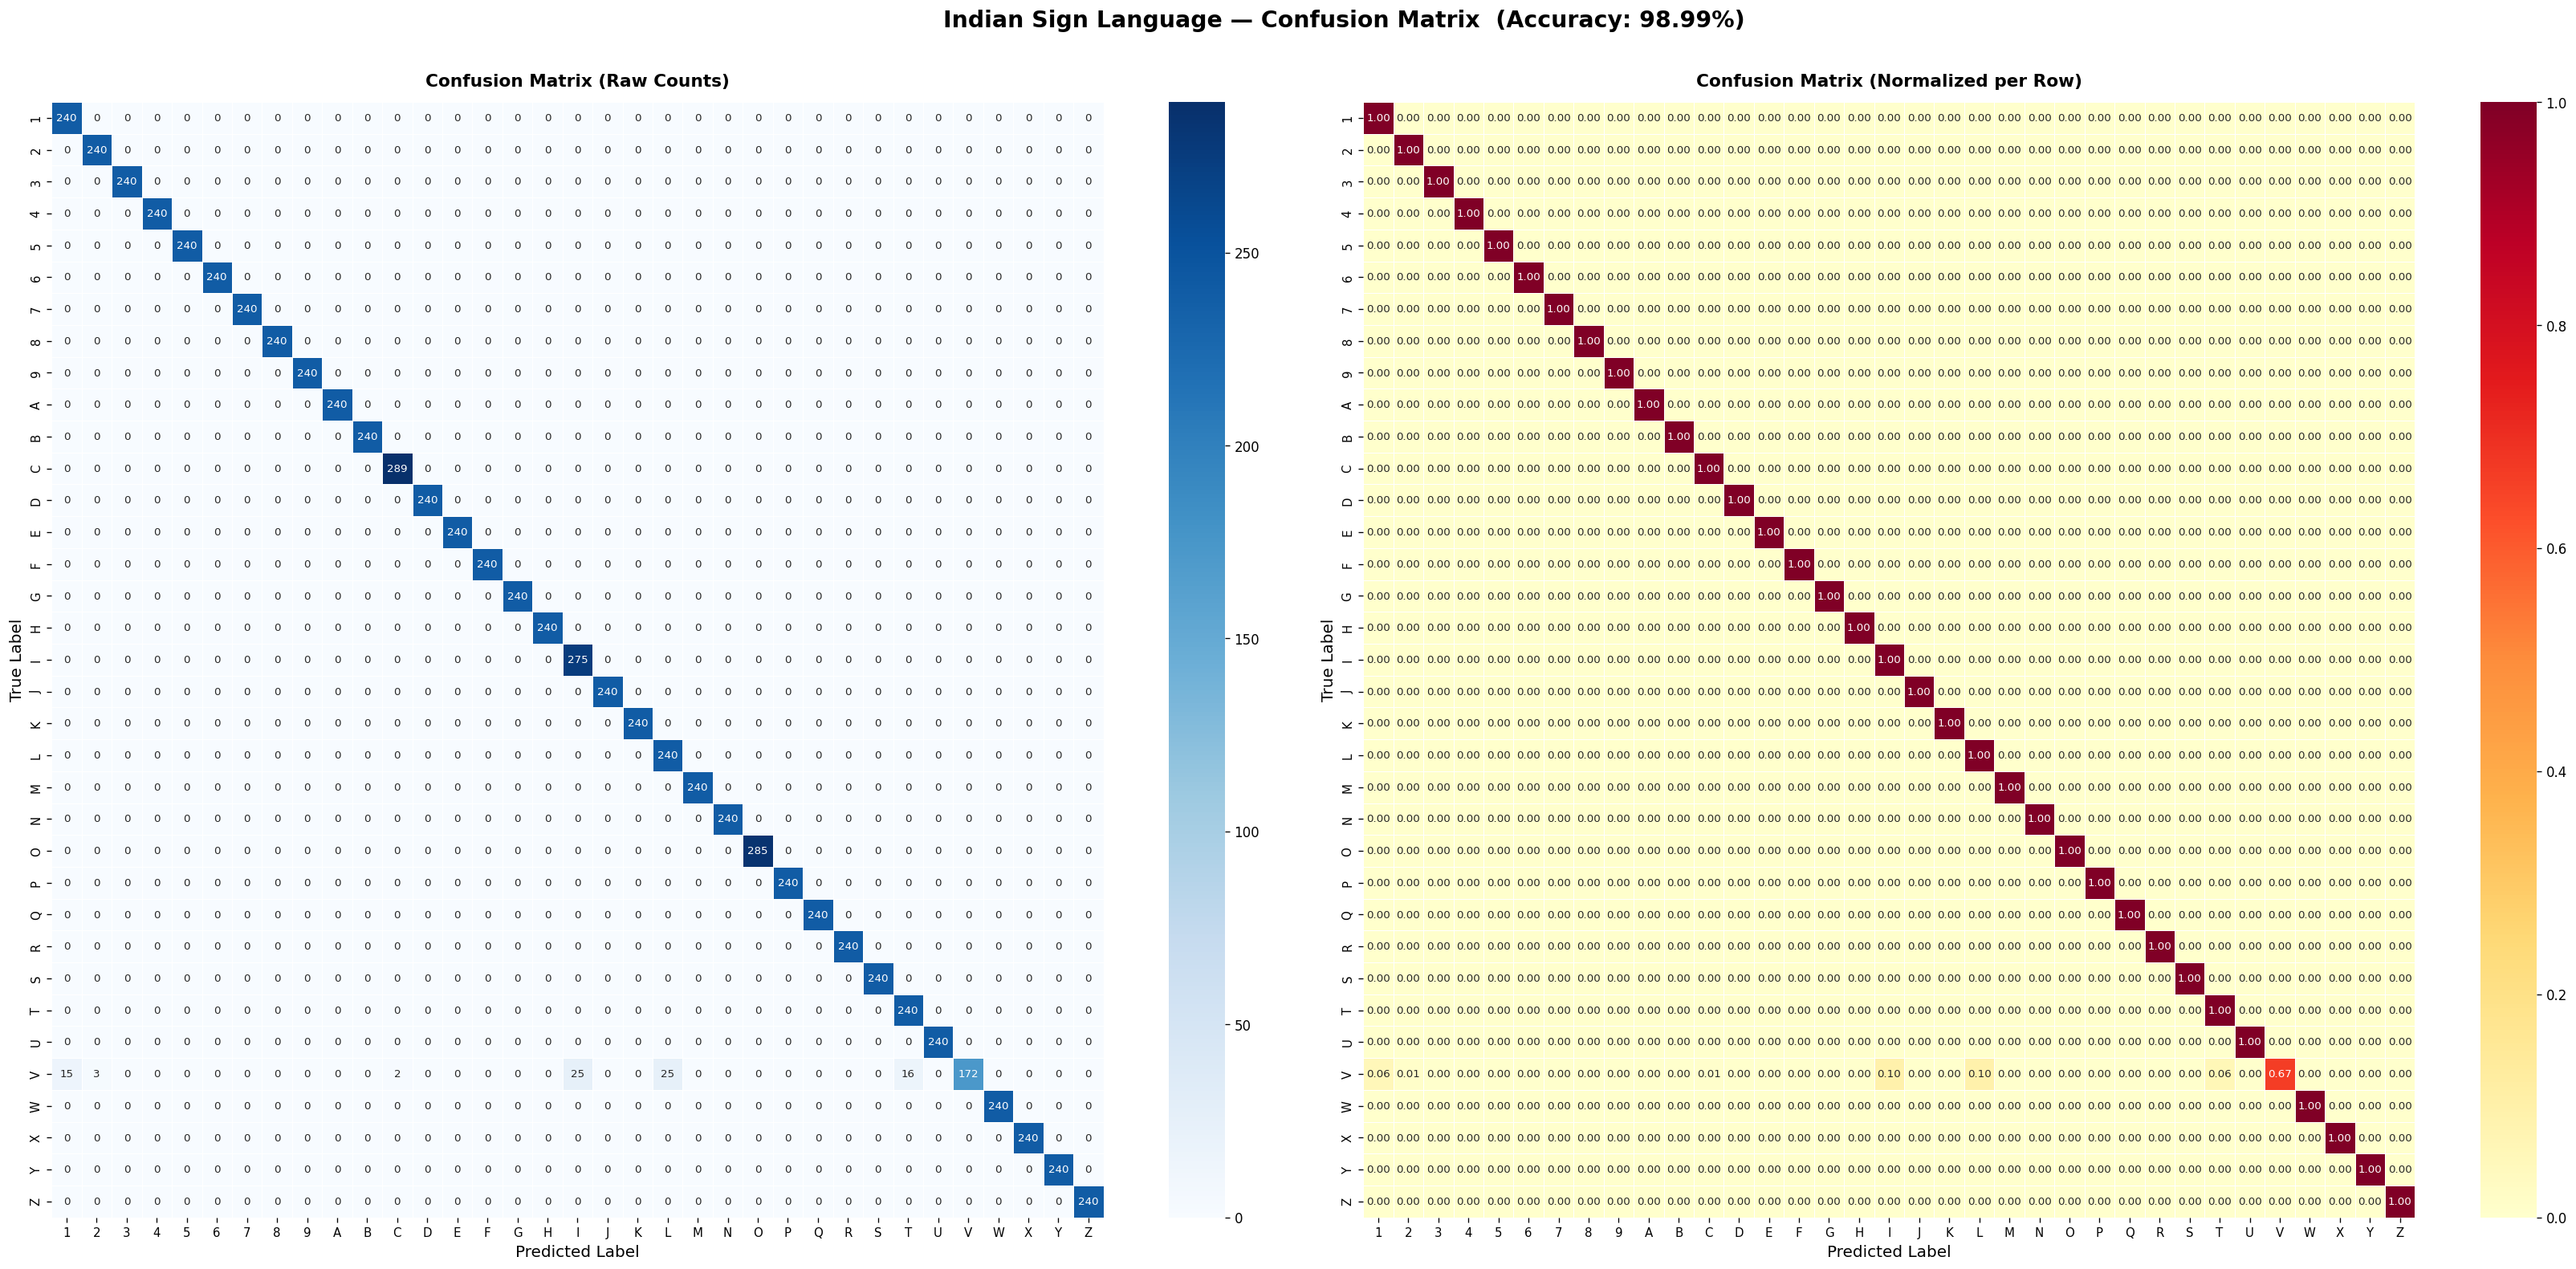

 Confusion matrix saved.

 Diagonal Dominance: 98.99% of predictions on diagonal
    STRONG diagonal dominance achieved!


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 10: GENERATE & PLOT CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────

print('Generating predictions on validation set...')
val_generator.reset()

# Get predictions for all validation samples
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)   # Predicted class indices
y_true       = val_generator.classes              # True class indices

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize for percentage display
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Overall accuracy
overall_acc = accuracy_score(y_true, y_pred)
print(f'\nValidation Accuracy (from predictions): {overall_acc * 100:.2f}%')

# ── Plot Confusion Matrix ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(28, 13))
fig.suptitle(f'Indian Sign Language — Confusion Matrix  (Accuracy: {overall_acc*100:.2f}%)',
             fontsize=17, fontweight='bold', y=1.01)

# Raw counts
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES,
    linewidths = 0.5,
    linecolor  = 'white',
    ax         = axes[0],
    annot_kws  = {'size': 8}
)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='both', labelsize=9)

# Normalized (percentage per class)
sns.heatmap(
    cm_normalized,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'YlOrRd',
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES,
    linewidths = 0.5,
    linecolor  = 'white',
    vmin       = 0,
    vmax       = 1,
    ax         = axes[1],
    annot_kws  = {'size': 8}
)
axes[1].set_title('Confusion Matrix (Normalized per Row)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Confusion matrix saved.')

# Diagonal dominance check
diag_sum  = np.trace(cm)
total_sum = cm.sum()
diag_pct  = diag_sum / total_sum * 100
print(f'\n Diagonal Dominance: {diag_pct:.2f}% of predictions on diagonal')
if diag_pct >= 90:
    print('    STRONG diagonal dominance achieved!')
elif diag_pct >= 80:
    print('    Good diagonal — consider more fine-tuning for stronger dominance.')
else:
    print('    Diagonal weak — increase epochs or adjust augmentation.')

## STEP 11: Classification Report

         CLASSIFICATION REPORT — Indian Sign Language Detection
              precision    recall  f1-score   support

           1     0.9412    1.0000    0.9697       240
           2     0.9877    1.0000    0.9938       240
           3     1.0000    1.0000    1.0000       240
           4     1.0000    1.0000    1.0000       240
           5     1.0000    1.0000    1.0000       240
           6     1.0000    1.0000    1.0000       240
           7     1.0000    1.0000    1.0000       240
           8     1.0000    1.0000    1.0000       240
           9     1.0000    1.0000    1.0000       240
           A     1.0000    1.0000    1.0000       240
           B     1.0000    1.0000    1.0000       240
           C     0.9931    1.0000    0.9966       289
           D     1.0000    1.0000    1.0000       240
           E     1.0000    1.0000    1.0000       240
           F     1.0000    1.0000    1.0000       240
           G     1.0000    1.0000    1.0000       240
           H     

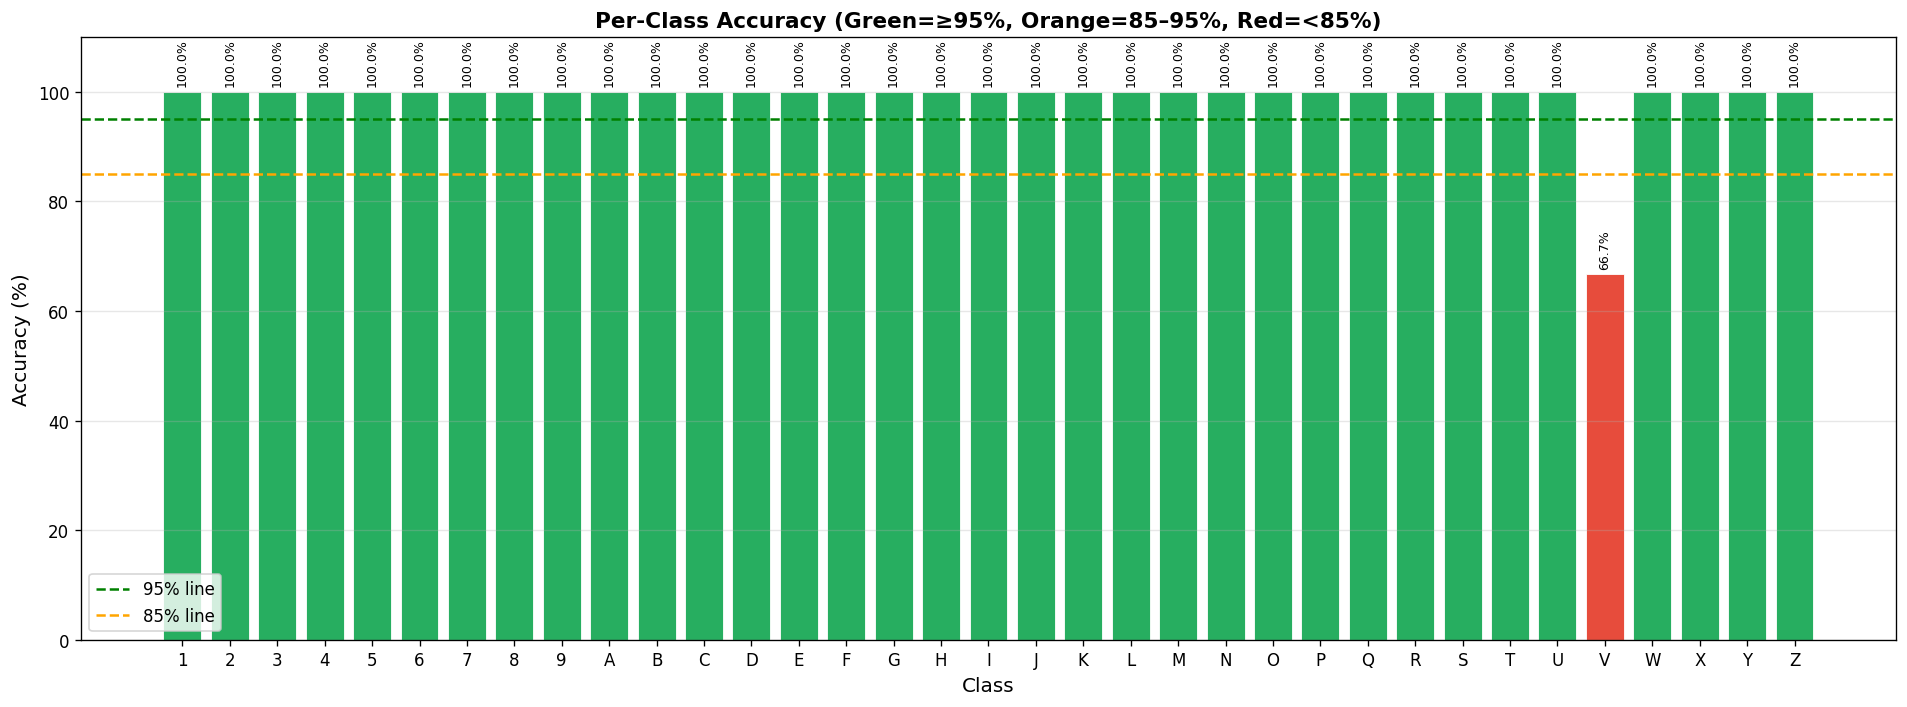

✅ Per-class accuracy chart saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 11: CLASSIFICATION REPORT (Precision / Recall / F1)
# ─────────────────────────────────────────────────────────────────

print('=' * 80)
print('         CLASSIFICATION REPORT — Indian Sign Language Detection')
print('=' * 80)
report = classification_report(
    y_true,
    y_pred,
    target_names = CLASS_NAMES,
    digits       = 4
)
print(report)
print('=' * 80)

# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#27ae60' if acc >= 0.95 else '#f39c12' if acc >= 0.85 else '#e74c3c'
          for acc in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=95, color='green',  linestyle='--', linewidth=1.5, label='95% line')
ax.axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='85% line')
ax.set_title('Per-Class Accuracy (Green=≥95%, Orange=85–95%, Red=<85%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim([0, 110])
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=7.5, rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Per-class accuracy chart saved.')

##  STEP 12: Sample Predictions

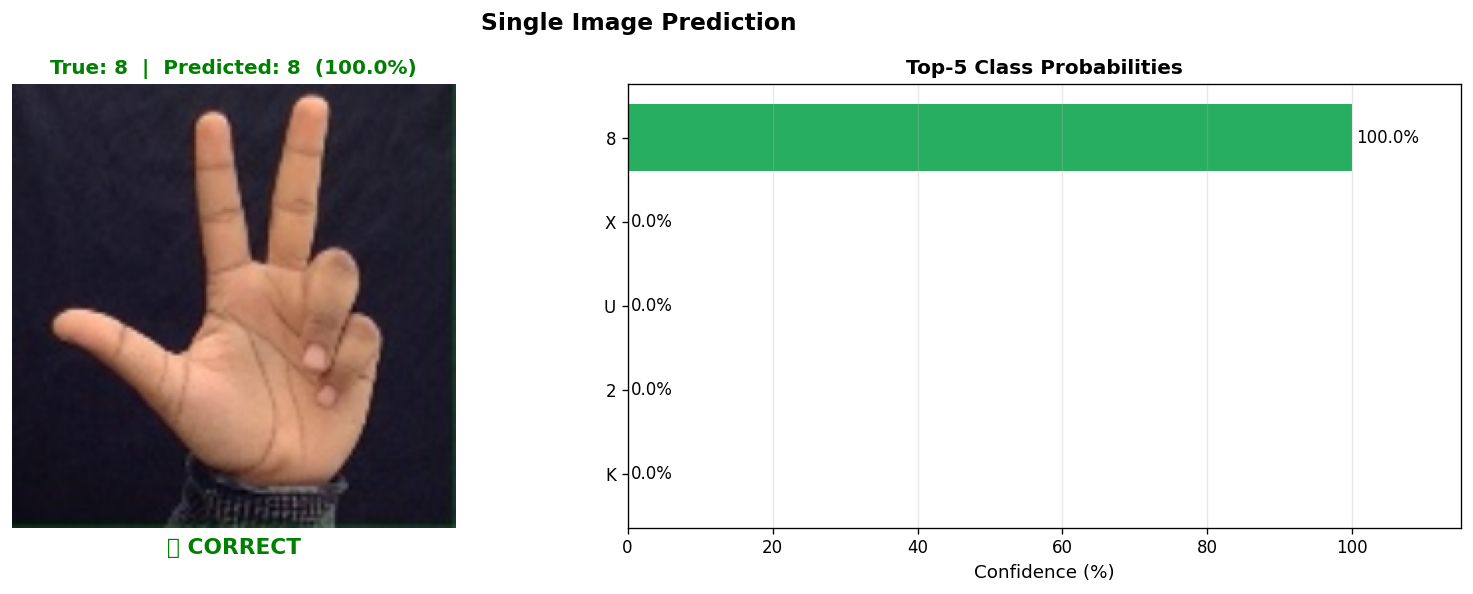


True Label : 8
Predicted  : 8
Confidence : 100.00%


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 12A: PREDICT ON A SINGLE IMAGE
# ─────────────────────────────────────────────────────────────────

def preprocess_image(image_path, target_size=(224, 224)):
    """Load, resize and normalize a single image for inference."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img_normalized = img.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)  # shape: (1, 224, 224, 3)
    return img, img_batch

def predict_single(image_path, model, class_names):
    """Run inference on a single image and return label + confidence."""
    img_display, img_input = preprocess_image(image_path)
    probs    = model.predict(img_input, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_cls = class_names[pred_idx]
    confidence = probs[pred_idx] * 100
    return img_display, pred_cls, confidence, probs

# ── Test on one random validation image ───────────────────────────
sample_cls  = random.choice(detected_classes)
sample_dir  = os.path.join(DATASET_PATH, sample_cls)
sample_file = random.choice([
    f for f in os.listdir(sample_dir)
    if f.lower().endswith(valid_extensions)
])
test_path   = os.path.join(sample_dir, sample_file)

img_disp, pred_label, confidence, probs = predict_single(test_path, model, CLASS_NAMES)

# Display
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Single Image Prediction', fontsize=14, fontweight='bold')

# Image panel
axes[0].imshow(img_disp)
color = 'green' if pred_label == sample_cls else 'red'
axes[0].set_title(
    f'True: {sample_cls}  |  Predicted: {pred_label}  ({confidence:.1f}%)',
    fontsize=12, fontweight='bold', color=color
)
axes[0].axis('off')
status = '✅ CORRECT' if pred_label == sample_cls else '❌ WRONG'
axes[0].text(0.5, -0.06, status, transform=axes[0].transAxes,
             ha='center', fontsize=13, color=color, fontweight='bold')

# Top-5 confidence bar chart
top5_idx  = np.argsort(probs)[::-1][:5]
top5_cls  = [CLASS_NAMES[i] for i in top5_idx]
top5_prob = [probs[i] * 100 for i in top5_idx]
bar_colors = ['#27ae60' if c == pred_label else '#3498db' for c in top5_cls]
axes[1].barh(top5_cls[::-1], top5_prob[::-1], color=bar_colors[::-1])
axes[1].set_xlabel('Confidence (%)', fontsize=11)
axes[1].set_title('Top-5 Class Probabilities', fontsize=12, fontweight='bold')
for i, (cls, prob) in enumerate(zip(top5_cls[::-1], top5_prob[::-1])):
    axes[1].text(prob + 0.5, i, f'{prob:.1f}%', va='center', fontsize=10)
axes[1].set_xlim([0, 115])
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'single_prediction.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nTrue Label : {sample_cls}')
print(f'Predicted  : {pred_label}')
print(f'Confidence : {confidence:.2f}%')

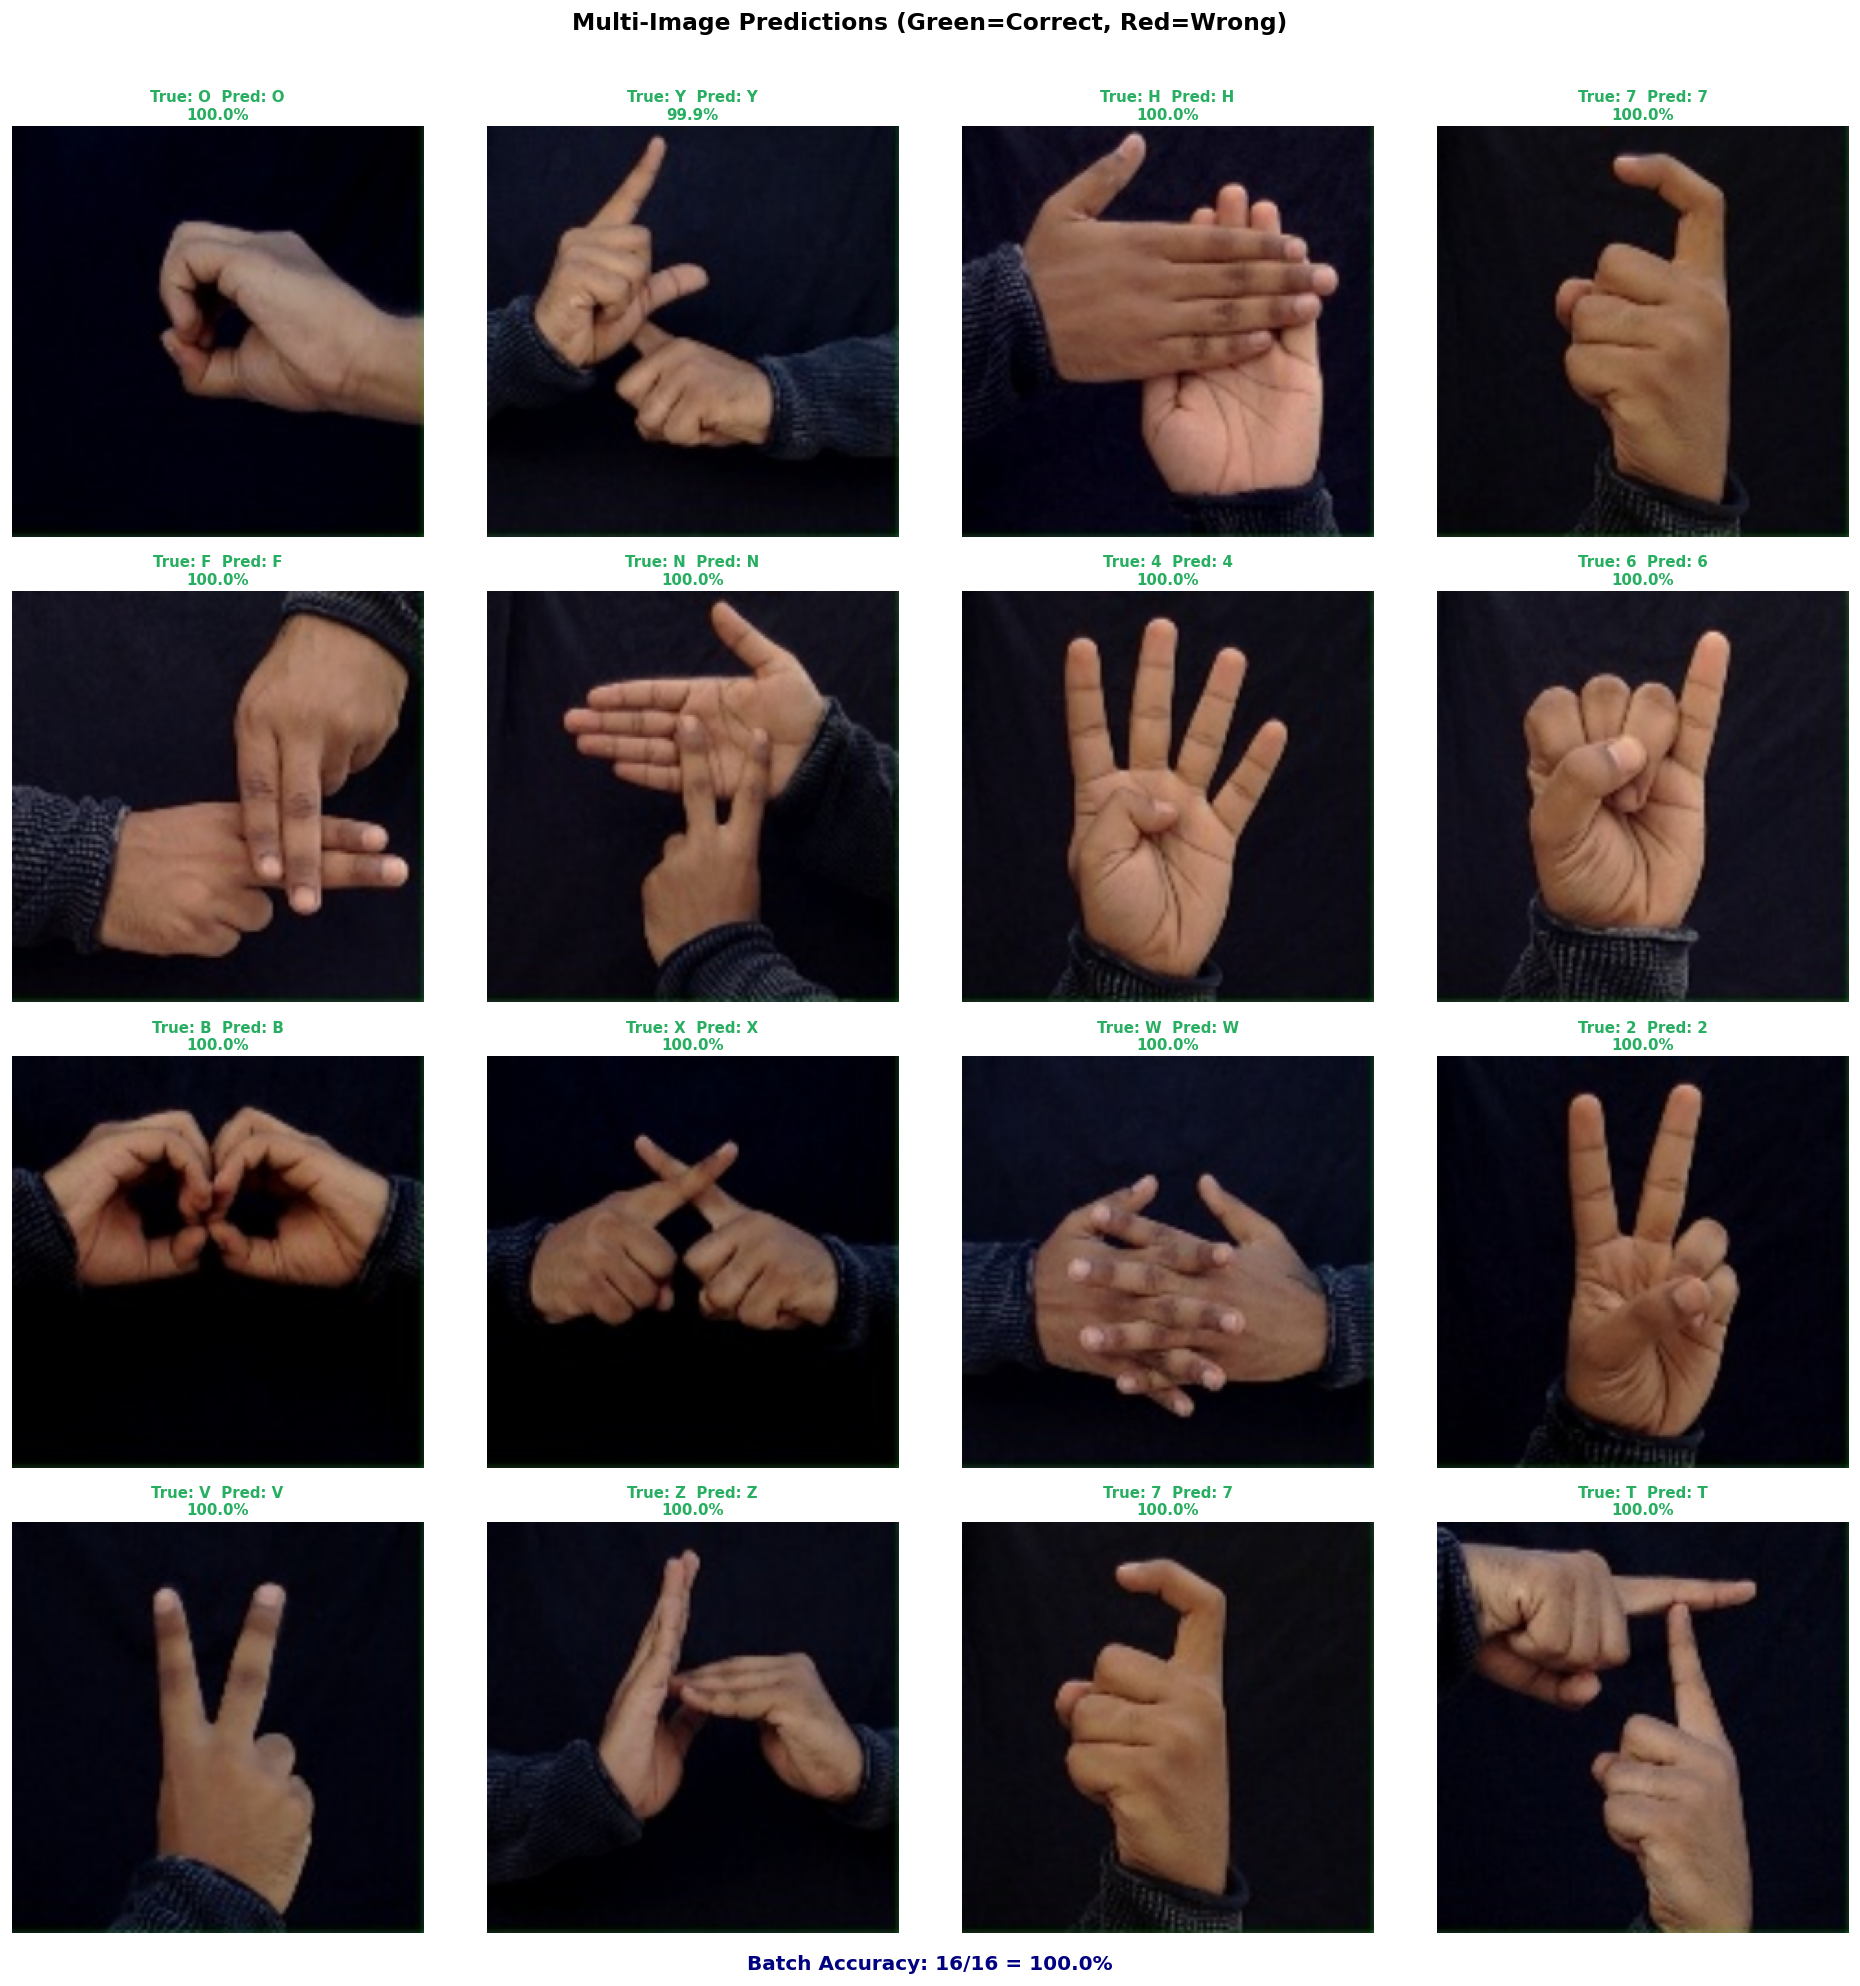

 Multi-image predictions saved. Batch acc: 100.0%


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 12B: PREDICT ON MULTIPLE RANDOM IMAGES (4x4 GRID)
# ─────────────────────────────────────────────────────────────────

def predict_multiple(dataset_path, model, class_names, n=16, grid=(4, 4)):
    """Show predictions on n random images in a grid."""
    # Collect all image paths
    all_paths = []
    for cls in os.listdir(dataset_path):
        cls_dir = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_dir): continue
        for f in os.listdir(cls_dir):
            if f.lower().endswith(valid_extensions):
                all_paths.append((os.path.join(cls_dir, f), cls))

    selected = random.sample(all_paths, min(n, len(all_paths)))

    fig, axes = plt.subplots(grid[0], grid[1], figsize=(16, 16))
    fig.suptitle('Multi-Image Predictions (Green=Correct, Red=Wrong)',
                 fontsize=14, fontweight='bold', y=1.01)

    correct_count = 0
    for idx, ax in enumerate(axes.flat):
        if idx >= len(selected):
            ax.axis('off')
            continue
        img_path, true_cls = selected[idx]
        img_disp, pred_cls, conf, _ = predict_single(img_path, model, class_names)
        is_correct = (pred_cls == true_cls)
        if is_correct:
            correct_count += 1
        color = '#27ae60' if is_correct else '#e74c3c'
        ax.imshow(img_disp)
        ax.set_title(f'True: {true_cls}  Pred: {pred_cls}\n{conf:.1f}%',
                     fontsize=9, color=color, fontweight='bold', pad=4)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.axis('off')

    batch_acc = correct_count / len(selected) * 100
    fig.text(0.5, -0.01,
             f'Batch Accuracy: {correct_count}/{len(selected)} = {batch_acc:.1f}%',
             ha='center', fontsize=12, color='navy', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'multi_predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f' Multi-image predictions saved. Batch acc: {batch_acc:.1f}%')

predict_multiple(DATASET_PATH, model, CLASS_NAMES, n=16)

##  STEP 13: Confidence Score Distribution

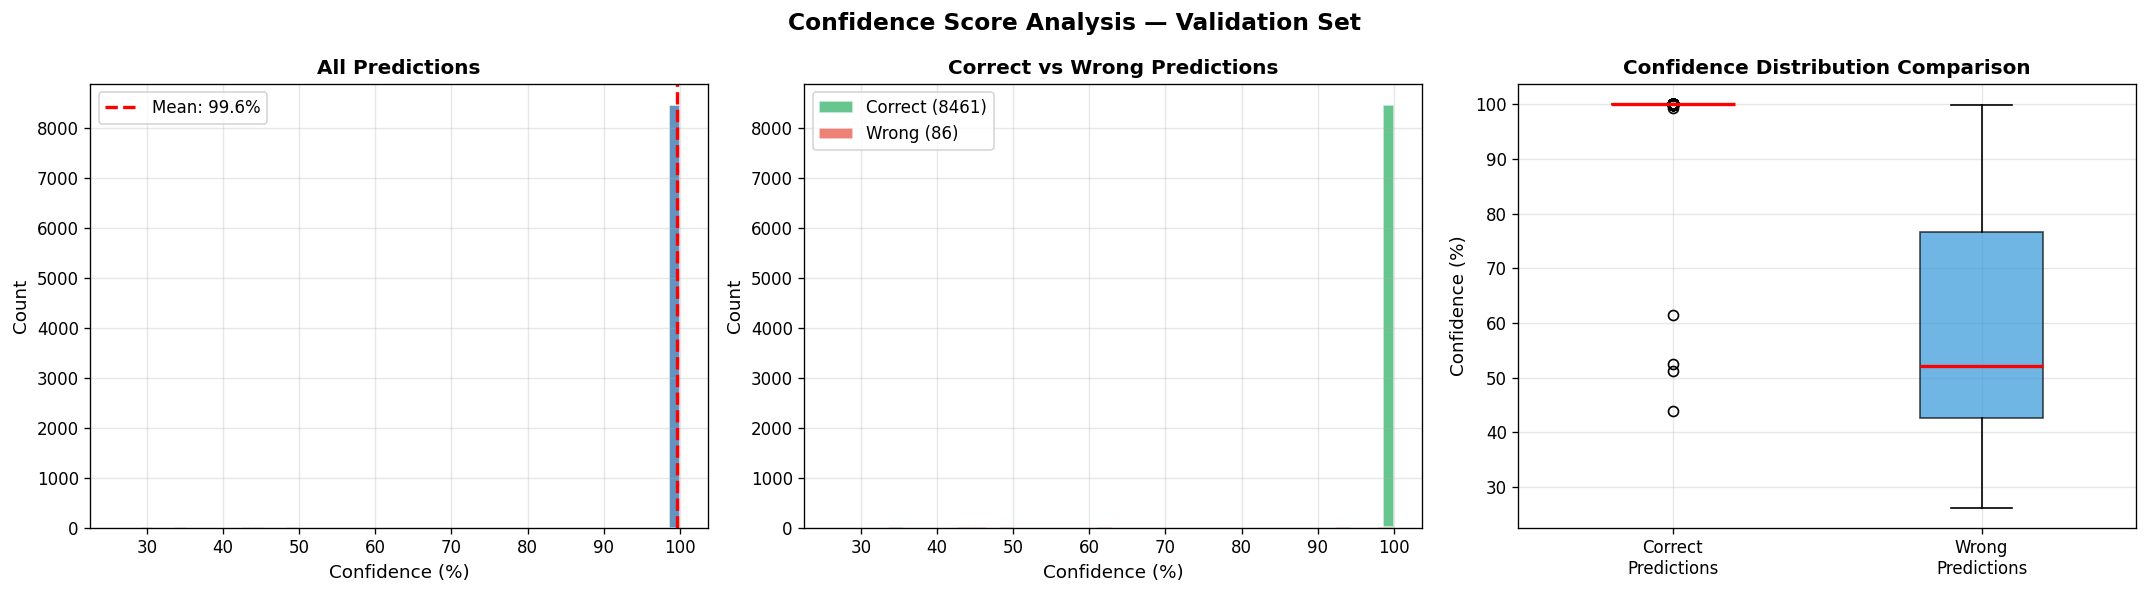


Confidence Score Statistics:
  All Predictions  — Mean: 99.56%  |  Std: 4.83%
  Correct Preds    — Mean: 99.98%  |  Std: 1.05%
  Wrong Preds      — Mean: 58.60%  |  Std: 22.63%
  High confidence (>90%): 8472 samples
  Low confidence  (<50%): 41 samples
✅ Confidence analysis saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 13: CONFIDENCE SCORE ANALYSIS
# ─────────────────────────────────────────────────────────────────

# Max confidence scores across all val predictions
max_confidence = y_pred_probs.max(axis=1) * 100

# Separate correct and wrong predictions
correct_mask  = (y_pred == y_true)
correct_conf  = max_confidence[correct_mask]
wrong_conf    = max_confidence[~correct_mask]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confidence Score Analysis — Validation Set', fontsize=14, fontweight='bold')

# All predictions histogram
axes[0].hist(max_confidence, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=max_confidence.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {max_confidence.mean():.1f}%')
axes[0].set_title('All Predictions', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence (%)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Correct vs wrong predictions
axes[1].hist(correct_conf, bins=40, color='#27ae60', edgecolor='white',
             alpha=0.7, label=f'Correct ({len(correct_conf)})')
axes[1].hist(wrong_conf, bins=40, color='#e74c3c', edgecolor='white',
             alpha=0.7, label=f'Wrong ({len(wrong_conf)})')
axes[1].set_title('Correct vs Wrong Predictions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence (%)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Box plot comparison
axes[2].boxplot([correct_conf, wrong_conf],
                labels=['Correct\nPredictions', 'Wrong\nPredictions'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                widths=0.4)
axes[2].set_title('Confidence Distribution Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Confidence (%)', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confidence_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nConfidence Score Statistics:')
print(f'  All Predictions  — Mean: {max_confidence.mean():.2f}%  |  Std: {max_confidence.std():.2f}%')
print(f'  Correct Preds    — Mean: {correct_conf.mean():.2f}%  |  Std: {correct_conf.std():.2f}%')
print(f'  Wrong Preds      — Mean: {wrong_conf.mean():.2f}%  |  Std: {wrong_conf.std():.2f}%')
print(f'  High confidence (>90%): {(max_confidence > 90).sum()} samples')
print(f'  Low confidence  (<50%): {(max_confidence < 50).sum()} samples')
print('Confidence analysis saved.')

## 💾 STEP 14: Save Model & Labels

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 14: SAVE MODEL (.h5) AND CLASS LABELS (.json & .npy)
# ─────────────────────────────────────────────────────────────────

# Save full Keras model in HDF5 format
model.save(MODEL_H5_PATH)
print(f' Model saved: {MODEL_H5_PATH}')
print(f'   File size  : {os.path.getsize(MODEL_H5_PATH) / 1e6:.2f} MB')

# Save class labels as JSON (human-readable)
labels_data = {
    'class_names'   : CLASS_NAMES,        # ['0','1',...,'9','A',...,'Z']
    'class_indices' : CLASS_INDICES,      # {'0': 0, '1': 1, ...}
    'num_classes'   : NUM_CLASSES,
    'image_size'    : list(IMG_SIZE),
    'model_name'    : 'ISL_MobileNetV2',
    'val_accuracy'  : float(val_acc)
}
with open(LABELS_PATH, 'w') as f:
    json.dump(labels_data, f, indent=2)
print(f' Labels saved: {LABELS_PATH}')

# Also save as NumPy array for quick loading
npy_path = os.path.join(OUTPUT_DIR, 'class_labels.npy')
np.save(npy_path, np.array(CLASS_NAMES))
print(f' NumPy labels: {npy_path}')

print(f'\nSaved Files:')
for f in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, f)
    size  = os.path.getsize(fpath) / 1024
    unit  = 'KB'
    if size > 1024:
        size /= 1024
        unit = 'MB'
    print(f'  {f:<35} {size:.1f} {unit}')

 Model saved: /content/isl_output/isl_model.h5
   File size  : 12.63 MB
 Labels saved: /content/isl_output/class_labels.json
 NumPy labels: /content/isl_output/class_labels.npy

Saved Files:
  isl_model.tflite                    3.2 MB
  isl_model.h5                        12.0 MB
  confidence_analysis.png             99.1 KB
  tflite_comparison.png               1.7 MB
  multi_predictions.png               3.1 MB
  sample_images.png                   2.9 MB
  class_labels.json                   0.9 KB
  augmentation_demo.png               162.5 KB
  class_labels.npy                    0.3 KB
  single_prediction.png               300.1 KB
  confusion_matrix.png                296.5 KB
  class_distribution.png              71.3 KB
  per_class_accuracy.png              71.8 KB
  training_history.png                128.9 KB
  best_model.h5                       29.8 MB


##  STEP 15: Download Model from Colab

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 15: DOWNLOAD MODEL & ARTIFACTS FROM COLAB
# ─────────────────────────────────────────────────────────────────

from google.colab import files

print('Downloading model files...')
print('(A download prompt will appear for each file)\n')

# Package all outputs into a zip for easy download
import zipfile
ZIP_PATH = '/content/isl_model_package.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(OUTPUT_DIR):
        fpath = os.path.join(OUTPUT_DIR, fname)
        zf.write(fpath, fname)
        print(f'  Added: {fname}')

zip_size = os.path.getsize(ZIP_PATH) / 1e6
print(f'\n Package created: {ZIP_PATH} ({zip_size:.1f} MB)')

# Download zip
files.download(ZIP_PATH)
print('\n Download initiated.')

(A download prompt will appear for each file)

  Added: isl_model.tflite
  Added: isl_model.h5
  Added: confidence_analysis.png
  Added: tflite_comparison.png
  Added: multi_predictions.png
  Added: sample_images.png
  Added: class_labels.json
  Added: augmentation_demo.png
  Added: class_labels.npy
  Added: single_prediction.png
  Added: confusion_matrix.png
  Added: class_distribution.png
  Added: per_class_accuracy.png
  Added: training_history.png
  Added: best_model.h5

 Package created: /content/isl_model_package.zip (51.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Download initiated.


## STEP 16: Convert to TFLite

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 16: CONVERT MODEL TO TFLITE (for Mobile Deployment)
# ─────────────────────────────────────────────────────────────────

print('Converting model to TensorFlow Lite...')

# Load best model
model_for_convert = keras.models.load_model(MODEL_H5_PATH)

# ── Standard TFLite Conversion ────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model_for_convert)

# Optimizations: reduce model size using dynamic range quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()

# Save TFLite model
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

h5_size     = os.path.getsize(MODEL_H5_PATH) / 1e6
tflite_size = os.path.getsize(TFLITE_PATH) / 1e6

print(f'\n TFLite model saved: {TFLITE_PATH}')
print(f'\nModel Size Comparison:')
print(f'  Original (.h5)   : {h5_size:.1f} MB')
print(f'  TFLite (.tflite) : {tflite_size:.1f} MB')
print(f'  Compression      : {(1 - tflite_size/h5_size)*100:.1f}% smaller')
print('\n TFLite model ready for Android/iOS/Edge deployment!')

# Download TFLite model
files.download(TFLITE_PATH)
files.download(LABELS_PATH)
print(' TFLite model and labels downloaded!')

Converting model to TensorFlow Lite...


Saved artifact at '/tmp/tmpkvev9418'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 35), dtype=tf.float32, name=None)
Captures:
  140665450356688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450353616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450355344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450354192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450355920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450353424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450358416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450349008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450354384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665450357840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14066545035688

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 TFLite model and labels downloaded!


## STEP 17: Test TFLite Model

In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 17: LOAD & TEST TFLITE MODEL — COMPARE WITH KERAS MODEL
# ─────────────────────────────────────────────────────────────────

class TFLiteInferenceEngine:
    """Wrapper for TFLite model inference."""

    def __init__(self, model_path, labels_path):
        # Load TFLite model and allocate tensors
        self.interpreter = tf.lite.Interpreter(model_path=model_path)
        self.interpreter.allocate_tensors()

        # Get input/output tensor details
        self.input_details  = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

        # Load class labels
        with open(labels_path) as f:
            data = json.load(f)
        self.class_names = data['class_names']

        print(f'TFLite Input  : {self.input_details[0]["shape"]}')
        print(f'TFLite Output : {self.output_details[0]["shape"]}')

    def predict(self, image_path):
        """Run inference on a single image."""
        # Preprocess
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=0)

        # Set input tensor
        self.interpreter.set_tensor(self.input_details[0]['index'], img)

        # Run inference
        self.interpreter.invoke()

        # Get output
        probs    = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
        pred_idx = np.argmax(probs)
        return self.class_names[pred_idx], probs[pred_idx] * 100, probs


# ── Initialize TFLite Engine ──────────────────────────────────────
print('Initializing TFLite Inference Engine...')
tflite_engine = TFLiteInferenceEngine(TFLITE_PATH, LABELS_PATH)

# ── Compare TFLite vs Keras on 10 random images ───────────────────
print('\nComparing TFLite vs Keras model on 10 test images:')
print('=' * 70)
print(f'{"Image":<8} {"True":>6} {"Keras Pred":>12} {"Keras Conf":>12} {"TFLite Pred":>13} {"TFLite Conf":>12} {"Match":>6}')
print('-' * 70)

matches = 0
test_paths_labels = []
for cls in random.sample(detected_classes, min(10, len(detected_classes))):
    cls_dir = os.path.join(DATASET_PATH, cls)
    fname = random.choice([
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(valid_extensions)
    ])
    test_paths_labels.append((os.path.join(cls_dir, fname), cls))

for i, (img_path, true_cls) in enumerate(test_paths_labels):
    # Keras prediction
    _, keras_pred, keras_conf, _ = predict_single(img_path, model, CLASS_NAMES)

    # TFLite prediction
    tflite_pred, tflite_conf, _ = tflite_engine.predict(img_path)

    match = '✅' if keras_pred == tflite_pred else '❌'
    if keras_pred == tflite_pred:
        matches += 1

    print(f'{i+1:<8} {true_cls:>6} {keras_pred:>12} {keras_conf:>10.1f}%  {tflite_pred:>12} {tflite_conf:>10.1f}%  {match:>6}')

print('=' * 70)
print(f'Agreement Rate: {matches}/10 ({matches*10}%)')
print('\n TFLite model verified and working correctly!')

Initializing TFLite Inference Engine...
TFLite Input  : [  1 224 224   3]
TFLite Output : [ 1 35]

Comparing TFLite vs Keras model on 10 test images:
Image      True   Keras Pred   Keras Conf   TFLite Pred  TFLite Conf  Match
----------------------------------------------------------------------
1             G            G      100.0%             G      100.0%       ✅
2             1            1      100.0%             1      100.0%       ✅
3             R            R      100.0%             R      100.0%       ✅
4             3            3      100.0%             3      100.0%       ✅
5             Y            Y      100.0%             Y      100.0%       ✅
6             V            V      100.0%             V      100.0%       ✅
7             5            5      100.0%             5      100.0%       ✅
8             Q            Q      100.0%             Q      100.0%       ✅
9             C            C      100.0%             C      100.0%       ✅
10            H            H

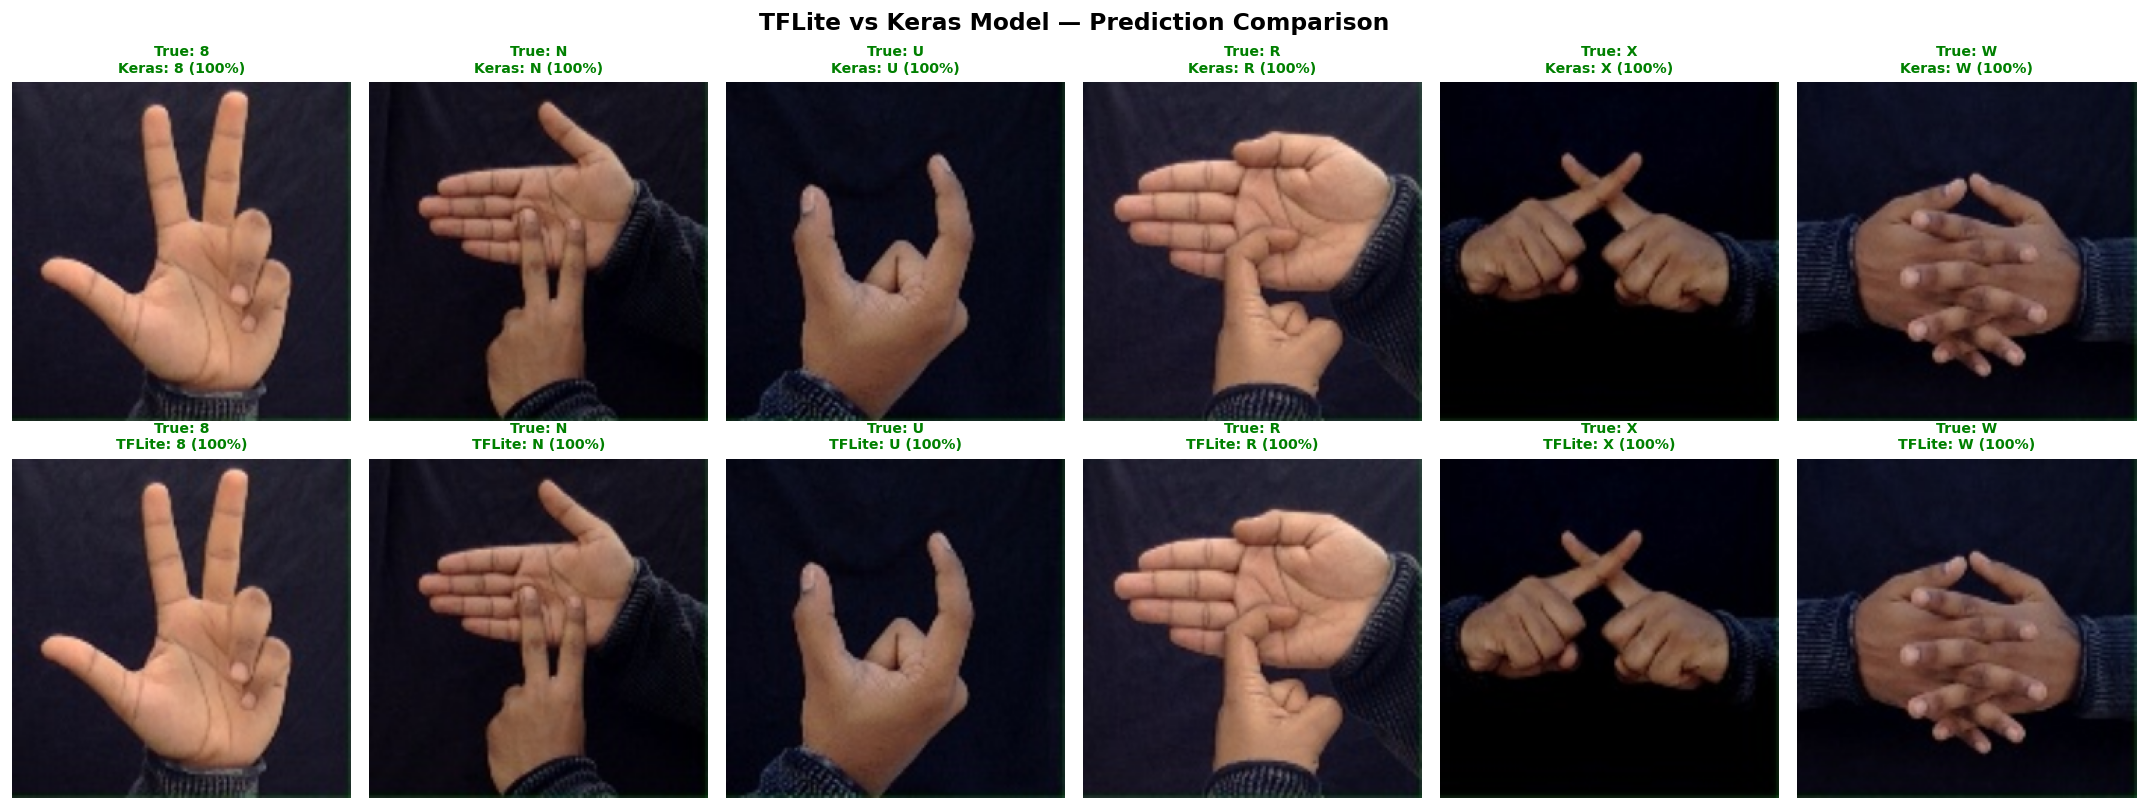

 TFLite comparison visualization saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 17B: VISUAL COMPARISON — TFLite vs Keras
# ─────────────────────────────────────────────────────────────────

n_compare = min(6, len(test_paths_labels))
fig, axes = plt.subplots(2, n_compare, figsize=(18, 7))
fig.suptitle('TFLite vs Keras Model — Prediction Comparison',
             fontsize=14, fontweight='bold')

for i in range(n_compare):
    img_path, true_cls = test_paths_labels[i]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    _, keras_pred, keras_conf, _  = predict_single(img_path, model, CLASS_NAMES)
    tflite_pred, tflite_conf, _ = tflite_engine.predict(img_path)

    # Row 0: Keras
    axes[0, i].imshow(img)
    k_color = 'green' if keras_pred == true_cls else 'red'
    axes[0, i].set_title(f'True: {true_cls}\nKeras: {keras_pred} ({keras_conf:.0f}%)',
                         fontsize=8.5, color=k_color, fontweight='bold')
    axes[0, i].axis('off')

    # Row 1: TFLite
    axes[1, i].imshow(img)
    t_color = 'green' if tflite_pred == true_cls else 'red'
    axes[1, i].set_title(f'True: {true_cls}\nTFLite: {tflite_pred} ({tflite_conf:.0f}%)',
                         fontsize=8.5, color=t_color, fontweight='bold')
    axes[1, i].axis('off')

# Row labels
axes[0, 0].set_ylabel('Keras\nModel', fontsize=11, fontweight='bold',
                       rotation=0, labelpad=50, color='#2980b9')
axes[1, 0].set_ylabel('TFLite\nModel', fontsize=11, fontweight='bold',
                       rotation=0, labelpad=50, color='#8e44ad')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tflite_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' TFLite comparison visualization saved.')

##  FINAL SUMMARY

In [ ]:
# ─────────────────────────────────────────────────────────────────
# FINAL PROJECT SUMMARY
# ─────────────────────────────────────────────────────────────────


print()
print('    INDIAN SIGN LANGUAGE DETECTION — PROJECT SUMMARY')
print()

print()
print('    DATASET')
print(f'       Total Images    : {total_images:,}')
print(f'       Total Classes   : {NUM_CLASSES} (A–Z + 0–9)')
print(f'       Train Samples   : {train_generator.n:,}')
print(f'       Val Samples     : {val_generator.n:,}')
print()
print('   MODEL')
print(f'       Architecture    : MobileNetV2 + Custom Head')
print(f'       Total Params    : {model.count_params():,}')
print(f'       Training Phases : 2 (Frozen → Fine-tuned)')
print(f'       Total Epochs    : {TOTAL_EPOCHS}')
print()
print('   PERFORMANCE')
print(f'       Validation Loss : {val_loss:.4f}')
print(f'       Validation Acc  : {val_acc * 100:.2f}%')
print(f'       Best Val Acc    : {max(HISTORY["val_accuracy"]) * 100:.2f}%')
print(f'       Avg Confidence  : {max_confidence.mean():.1f}%')
print()
print('    OUTPUTS SAVED')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f'        {fname:<35} ({size:.1f} MB)')
print()
print('    DEPLOYMENT READY')
print('        H5 model  — For Python/Server inference')
print('        TFLite    — For Android/iOS/Edge devices')
print('        Labels    — JSON + NumPy class mappings')
print()
status_icon = '🎉' if val_acc >= 0.95 else '✅'
print(f'    Final Status: {"TARGET ACHIEVED (>95%)" if val_acc >= 0.95 else "Complete — Fine-tune for >95%"}')
print()



    INDIAN SIGN LANGUAGE DETECTION — PROJECT SUMMARY


    DATASET
       Total Images    : 42,745
       Total Classes   : 35 (A–Z + 0–9)
       Train Samples   : 34,198
       Val Samples     : 8,547

   MODEL
       Architecture    : MobileNetV2 + Custom Head
       Total Params    : 3,061,347
       Training Phases : 2 (Frozen → Fine-tuned)
       Total Epochs    : 10

   PERFORMANCE
       Validation Loss : 0.1579
       Validation Acc  : 98.99%
       Best Val Acc    : 99.02%
       Avg Confidence  : 99.6%

    OUTPUTS SAVED
        augmentation_demo.png               (0.2 MB)
        best_model.h5                       (31.3 MB)
        class_distribution.png              (0.1 MB)
        class_labels.json                   (0.0 MB)
        class_labels.npy                    (0.0 MB)
        confidence_analysis.png             (0.1 MB)
        confusion_matrix.png                (0.3 MB)
        isl_model.h5                        (12.6 MB)
        isl_model.tflite            



```
# This is formatted as code
```

## Real-Time Webcam Prediction


In [ ]:
# ─────────────────────────────────────────────────────────────────
# WEBCAM CAPTURE + REAL-TIME PREDICTION IN COLAB
# ─────────────────────────────────────────────────────────────────
# This captures a snapshot from your webcam and runs ISL prediction.

from IPython.display import display, Javascript, Image as IPImage
from google.colab.output import eval_js
from base64 import b64decode
import io

def capture_webcam_image():
    """Capture a single image from the webcam in Colab."""
    js = Javascript('''
        async function captureImage() {
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();
            await new Promise(r => setTimeout(r, 1000)); // warm-up
            const canvas = document.createElement('canvas');
            canvas.width = 224; canvas.height = 224;
            canvas.getContext('2d').drawImage(video, 0, 0, 224, 224);
            stream.getTracks().forEach(t => t.stop());
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        captureImage().then(data => element.textContent = data);
    ''')
    display(js)
    data_url = eval_js('captureImage()')
    header, encoded = data_url.split(',', 1)
    img_bytes = b64decode(encoded)
    return img_bytes

def webcam_predict():
    """Capture from webcam and predict ISL sign."""
    print(' Accessing webcam... Show a hand sign to the camera!')
    img_bytes = capture_webcam_image()

    # Save temporarily
    tmp_path = '/tmp/webcam_capture.jpg'
    with open(tmp_path, 'wb') as f:
        f.write(img_bytes)

    # Load and predict
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB').resize(IMG_SIZE)
    img_arr = np.array(img).astype('float32') / 255.0
    img_input = np.expand_dims(img_arr, axis=0)
    probs    = model.predict(img_input, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_cls = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

    # Display result
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img)
    axes[0].set_title(f'Predicted: {pred_cls}  ({confidence:.1f}%)',
                      fontsize=14, fontweight='bold', color='#2c3e50')
    axes[0].axis('off')
    top5_idx  = np.argsort(probs)[::-1][:5]
    top5_cls  = [CLASS_NAMES[i] for i in top5_idx]
    top5_prob = [probs[i] * 100 for i in top5_idx]
    axes[1].barh(top5_cls[::-1], top5_prob[::-1],
                 color=['#27ae60' if c == pred_cls else '#3498db' for c in top5_cls[::-1]])
    axes[1].set_title('Top-5 Predictions', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Confidence (%)')
    plt.tight_layout()
    plt.show()
    print(f' Detected Sign: "{pred_cls}" with {confidence:.1f}% confidence')

# Uncomment to run live webcam prediction:
# webcam_predict()
print(' Webcam prediction function ready!')
print('   Call webcam_predict() to capture and classify a sign.')

 Webcam prediction function ready!
   Call webcam_predict() to capture and classify a sign.
